# Novelty-Driven Mean Reversion
### A Portfolio Sort Study of Earnings Call Text (FIN 285F)
**Authoritative steps** follow **`project_specification_rio_zac.pdf`**. This notebook mirrors the memo’s section order; cell headings below cite the PDF §. We reconstruct **turn/segment text** using `transcript_speaker_indices.csv` (and default to **Q&A-only**). If a transcript can’t be aligned to turn/chunk segments, we fall back to sentence-level splits on `full_transcript_text` and note it.

### Project steps (PDF → notebook)

1. **§1 Introduction** — Semantic novelty vs a firm’s own past language; build an **impact-aware** text signal (novelty × √salience × LLM impact) and test whether it predicts returns. *Context:* this header and §10.
2. **§2 Research question & hypotheses** — **H1 (impact-aware):** firms with **novel, salient, positive-impact** Q&A statements **outperform** firms with **novel, salient, negative-impact** Q&A statements (portfolio **long Q5 / short Q1** on the signed impact-adjusted signal). **H2:** the **event-window response** differs by quintile (Q5 vs Q1) and the sign/direction is consistent with the impact label (check **CAR[−1,+1]** and **CAR[+2,+5]**). **H3:** FinBERT positive tone × novelty (optional). *Notebook:* §7 (event paths), §6b (regressions / FF5).
3. **§3 Data sources & definitions** — Returns (`ret_t-15` … `ret_t+15`, overnight), identifiers (`permno`), `full_transcript_text`, and **constructed variables**: embedding novelty, lexical baselines (TF‑IDF / BM25 in memo), salience, LLM gate, SUE, macro penalty, section/analyst/topic weights (staged as data allow). *Notebook:* §1 load; §2–§6 NLP and merges.
4. **§4 Data policy & governance** — Sample rules: earnings calls, non-missing **`permno`**, **`word_count` ≥ 100**, **≥ 2** prior transcripts, **non-missing returns on [−1, +5]**; winsorize returns and overnight at **1st / 99th**; no look-ahead in baselines. *Notebook:* §1b + `nh.apply_project_spec_sample_pipeline` (`SAMPLE_FLOW`).
5. **§5 Exploratory data analysis** — Summary stats, return and text distributions, time coverage. *Notebook:* §1 preview cell; §8 diagnostics (extend with memo-style tables as needed).
6. **§6 Portfolio construction** — Within-quarter **quintiles** on the **signed impact-adjusted** signal; **long Q5 / short Q1** (positive vs negative impact); **quarterly** rebalance and holding period per memo; equal-weight baseline. *Notebook:* §7 implements an **event-window / CAR-style supplement** (memo §6.4); full **calendar-time quarterly sort** is the next build to match §6.1–6.3 exactly.
7. **§7 Model specification** — Risk-adjust returns (e.g. **Fama–French 5-factor**), **SUE** and **`pre_drift`** controls, clustered inference. *Notebook:* §6b (`nh.fit_ols_cluster`, FF5).

**Appendices (memo)** — **A** salience clusters → `salience_dictionary.py`; **B** NLP parameters → embedding / threshold config cells; **C** variable definitions → `novelty_helpers.py`; **D** sample construction flow → §1b `SAMPLE_FLOW`.

### NLP execution order (implements §3.3 precision gate + macro)
1. **Lexical baseline (TF‑IDF)** — per-firm rolling profile (memo lexical robustness path; also supports interpretation).
2. **Semantic novelty** — encoder + distance to historical centroid on **turn-aligned** segments (memo primary: **nomic-embed-text-v1.5**; notebook default `all-MiniLM-L6-v2` until swapped).
3. **Salience ≥ 0.30** and **novelty ≥ 0.60** → **Ollama** verbatim §3.3 YES/NO prompt → **LLM = YES** required for gated rows.
4. **Cross-market penalty** — sigmoid in cluster frequency (**f₀=0.40**, **k=15**); notebook uses **quarter × cluster** as proxy until trailing **three-month** prior window is merged (memo §3.3 / §4.4).
5. **Impact-adjusted novelty** (novelty × √salience × LLM impact × macro penalty) → firm-event aggregation and within-quarter **quintiles** for sorts.

**Current run scope / caveats:** Results here are computed on the **Top 50 S&P 500 constituents by index weight** for tractability. This is **not** a clean cross-section for inference (selection/survivorship effects; “good stocks vs good stocks”), so treat performance plots as **illustrative** until we expand the universe.

**Q&A focus:** We default to **Q&A-only** segments (prepared remarks are excluded) because the prepared section often restates information already released in the earnings report; the goal is to isolate incremental information revealed in analyst questions and management answers.

> **Embeddings:** Not FinBERT for novelty geometry; memo encoder is **Nomic**; **H3** uses FinBERT **tone** separately.
>
> **Dev runs:** `_DEV_TICKERS_RAW` in §0 → scoped `*__dev_*.pkl` caches; `None` = full panel.


In [1]:
# ── Google Colab Setup ────────────────────────────────────────────────────────
# 1. Mount Google Drive   (datasets live in My Drive/FIN285F-Project-Dataset)
# 2. Clone the GitHub repo (helper scripts: novelty_helpers.py, etc.)
# 3. Symlink datasets from Drive into the repo's final_project/ directory
# 4. Install Python dependencies

from google.colab import drive
drive.mount('/content/drive')

import os, glob, shutil

# ── Paths ──
GDRIVE_DATASET = "/content/drive/MyDrive/FIN285F-Project-Dataset-Zac"
REPO_DIR       = "/content/wrds"
PROJECT_DIR    = os.path.join(REPO_DIR, "final_project")

assert os.path.isdir(GDRIVE_DATASET), (
    f"Drive folder not found: {GDRIVE_DATASET}\n"
    "Create it in Google Drive → My Drive → FIN285F-Project-Dataset "
    "and upload FINAL.csv + transcript_speaker_indices.csv."
)

# ── Clone repo (helper scripts, salience_dictionary, cohen_portfolio, etc.) ──
if not os.path.isdir(REPO_DIR):
    !git clone https://github.com/zac-garland/wrds.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull --ff-only
print(f"Repo ready: {REPO_DIR}")

# ── Symlink dataset files from Drive into final_project/ ──
_dataset_files = ["FINAL.csv", "transcript_speaker_indices.csv"]
for fname in _dataset_files:
    src = os.path.join(GDRIVE_DATASET, fname)
    dst = os.path.join(PROJECT_DIR, fname)
    if os.path.isfile(src) and not os.path.exists(dst):
        os.symlink(src, dst)
        print(f"Linked {fname} → Drive")
    elif os.path.exists(dst):
        print(f"{fname} already in project dir")
    else:
        print(f"WARNING: {fname} not found in {GDRIVE_DATASET}")

# ── Symlink pkl_cache on Drive for persistent caching across sessions ──
_drive_cache = os.path.join(GDRIVE_DATASET, "pkl_cache")
_proj_cache  = os.path.join(PROJECT_DIR, "pkl_cache")
os.makedirs(_drive_cache, exist_ok=True)
if not os.path.exists(_proj_cache):
    os.symlink(_drive_cache, _proj_cache)
    print(f"Linked pkl_cache/ → Drive (persistent across sessions)")
else:
    print("pkl_cache/ already exists")

# ── Set working directory to final_project/ ──
os.chdir(PROJECT_DIR)

# ── Install dependencies not pre-installed on Colab ──
!pip install -q sentence-transformers statsmodels

print(f"\nWorking directory: {os.getcwd()}")
print(f"Files: {sorted(os.listdir('.'))[:30]}")

Mounted at /content/drive
Cloning into '/content/wrds'...
remote: Enumerating objects: 410, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (139/139), done.
remote: Total 410 (delta 128), reused 154 (delta 73), pack-reused 189 (from 2)
Receiving objects: 100% (410/410), 141.76 MiB | 19.17 MiB/s, done.
Resolving deltas: 100% (159/159), done.
Repo ready: /content/wrds
Linked FINAL.csv → Drive
Linked transcript_speaker_indices.csv → Drive
Linked pkl_cache/ → Drive (persistent across sessions)

Working directory: /content/wrds/final_project
Files: ['Apr_9th.ipynb', 'FINAL.csv', 'TODO-Apr15', 'TURN_NOVELTY_AUDIT.md', 'audit_top10.py', 'backtest_results.png', 'change_audit_runner.py', 'chunk_to_component.csv', 'cluster_distribution.png', 'cohen_portfolio.py', 'earnings_eda4.qmd', 'earnings_eda_finbert_scale.ipynb', 'iterations', 'llm_impact_vs_overnight.png', 'make_audit_notebooks.py', 'novelty_distribution.png', 'novelty_driven_mean_reversion copy.ipy

## 0. Environment & Imports

In [2]:
# Install dependencies if needed
# !pip install sentence-transformers scikit-learn pandas numpy statsmodels

import warnings
warnings.filterwarnings("ignore")

import sys, os, re, json, pickle
import importlib.util
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Sentence embeddings — semantic encoder, NOT FinBERT (sentiment classifier)
from sentence_transformers import SentenceTransformer

# Project root: cwd, cwd/final_project, or any parent/*/final_project (robust to Jupyter cwd).
def _final_project_root() -> Path:
    here = Path.cwd().resolve()
    for c in (here, here / "final_project"):
        if (c / "novelty_helpers.py").is_file():
            return c.resolve()
    for base in here.parents:
        fp = base / "final_project" / "novelty_helpers.py"
        if fp.is_file():
            return fp.parent.resolve()
    raise FileNotFoundError(
        "novelty_helpers.py not found — open a terminal in `final_project` or run Jupyter with cwd there."
    )


def _load_novelty_helpers(project_root: Path):
    """Load `novelty_helpers.py` by path so a different package named novelty_helpers cannot shadow it."""
    path = project_root / "novelty_helpers.py"
    spec = importlib.util.spec_from_file_location("novelty_helpers", path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Cannot load {path}")
    mod = importlib.util.module_from_spec(spec)
    sys.modules["novelty_helpers"] = mod
    spec.loader.exec_module(mod)
    return mod


_PROJECT_ROOT = _final_project_root()
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

# Salience dictionary — same directory as novelty_helpers.py
from salience_dictionary import score_sentence, SALIENCE_DICT

if "novelty_helpers" in sys.modules:
    del sys.modules["novelty_helpers"]
nh = _load_novelty_helpers(_PROJECT_ROOT)

# --- Semantic encoder: change only these when moving to Nomic (then delete/rename pickle caches) ---
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"  # later: e.g. "BAAI/bge-small-en-v1.5" if exposed via sentence-transformers
EMBEDDING_CACHE_TAG = "novelty_all_mini"  # bump when novelty geometry/segmentation changes

# Dev: small ticker sample (e.g. 3 names) for fast runs. Uses *__dev_AAPL_MSFT_NVDA.pkl sidecars;
# falls back to slicing the full pickle if a dev file does not exist yet. None = full panel.
_DEV_TICKERS_RAW =  None
# _DEV_TICKERS_RAW =  ("AAPL","MSFT","NVDA") #  None = all rows in top50 below
DEV_TICKERS = nh.dev_tickers_normalized(_DEV_TICKERS_RAW)
# After changing this or the ticker list, re-run: df → turn-index cell → baselines → novelty (pickles are dev-scoped).


def embedding_cache_path(stem: str) -> Path:
    """Pickle path keyed by EMBEDDING_CACHE_TAG so a new encoder does not clobber old caches."""
    cache_dir = Path("./pkl_cache")
    cache_dir.mkdir(parents=True, exist_ok=True)
    if EMBEDDING_CACHE_TAG == "default":
        return cache_dir / f"{stem}.pkl"
    return cache_dir / f"{stem}_{EMBEDDING_CACHE_TAG}.pkl"


print("All imports OK")
print(f"Salience clusters: {len(SALIENCE_DICT)}")
print(f"Embedding model: {EMBEDDING_MODEL_NAME} | cache tag: {EMBEDDING_CACHE_TAG}")
if DEV_TICKERS:
    print(f"DEV_TICKERS={DEV_TICKERS!r} — dev sample mode (scoped cache files)")


All imports OK
Salience clusters: 26
Embedding model: all-MiniLM-L6-v2 | cache tag: novelty_all_mini


In [3]:
# ---------------------------
# Run configuration (all knobs)
# ---------------------------
from multiprocessing import cpu_count
# Universe sharding (for Zac/Rio split)
RUN_SHARD = "zac"  # "zac" | "rio" | "all"

# Multiprocessing (CPU-bound steps)
TFIDF_N_WORKERS= (max(1, cpu_count() - 1))       # None => auto (max(1, cpu_count() - 1))
SALIENCE_N_WORKERS= (max(1, cpu_count() - 1))    # None => auto (max(1, cpu_count() - 1))

# Signal thresholds (PDF §3.3 precision gate)
NOVELTY_THRESHOLD = 0.60
SALIENCE_THRESHOLD = 0.30

# LLM inference (vLLM with OpenAI-compatible API)
LLM_MODEL = "meta-llama/Meta-Llama-3.1-8B-Instruct"
LLM_BASE_URL = "http://127.0.0.1:8000/v1"

LLM_HTTP_TIMEOUT = 120.0
LLM_MAX_RETRIES = 3
LLM_RETRY_BASE_SEC = 2.0
LLM_RETRY_MAX_SLEEP = 16.0

# Parallelism for LLM (vLLM handles batching internally; more workers = more concurrent requests)
LLM_MAX_WORKERS = 10
LLM_IMPACT_WORKERS = 10

# Checkpointing (disk cache write frequency)
LLM_CACHE_SAVE_EVERY = 25
IMPACT_CACHE_SAVE_EVERY = 200
SAL_CACHE_SAVE_EVERY = 2000

In [4]:
# (placeholder cell; safe to ignore)

## 1. Data load — PDF §3 (sources & definitions)

**PDF §3.1–3.2:** financial fields (daily returns around the call, overnight return, `permno`, event dates) and **text** (`full_transcript_text`). **`FINAL.csv`** is the working extract (~181k calls). The next cell **previews** columns without loading full text; the following cell loads `USE_COLS` via `novelty_helpers` (**returns** `ret_t-15` … `ret_t15`, **I/B/E/S** / SUE, **Compustat** links, **`full_transcript_text`**).

**Not in file:** market capitalization (merge from CRSP/Compustat by `permno`/`gvkey` when you add size controls). **Turn metadata** is merged from **`transcript_speaker_indices.csv`** (same folder as this notebook).

**Vs. prior `aggregated_all_years_updated_event.csv`:** Same column names for every field that existed before; `FINAL.csv` only **adds** Compustat/I-B-E-S link columns (no renames, no dropped core fields). The event panel is **slightly smaller** (stricter sample / merge), so a handful of `transcriptid`s differ from the old file.

**Turn NLP caches:** With `EMBEDDING_CACHE_TAG = "turns"`, novelty/baseline pickles are **`novelty_*_turns.pkl`**; re-run the baseline + novelty cells after changing the ticker panel, `transcript_speaker_indices.csv`, or the encoder.

In [5]:
# Preview FINAL.csv shape & key fields (excludes full_transcript_text for speed)
DATA_PATH = Path(".") / "FINAL.csv"
assert DATA_PATH.exists(), f"Data not found at {DATA_PATH.resolve()}"

RET_COLS = [f"ret_t{j}" for j in list(range(-15, 0)) + list(range(0, 16))]
all_cols = list(pd.read_csv(DATA_PATH, nrows=0).columns)
PREVIEW_COLS = [c for c in all_cols if c != "full_transcript_text"]
prev = pd.read_csv(DATA_PATH, usecols=PREVIEW_COLS, low_memory=False)

print("=== FINAL.csv (metadata / numeric columns only) ===")
print(f"Path:   {DATA_PATH.resolve()}")
print(f"Rows:   {len(prev):,}")
print(f"Cols:   {len(all_cols)} (including full_transcript_text)")
print(f"permno missing:     {prev['permno'].isna().sum():,}")
print(f"ibes_sue_eps nn:    {prev['ibes_sue_eps'].notna().sum():,}  (SUE)")
print(f"ibes_raw_surp nn:   {prev['ibes_raw_surp_eps'].notna().sum():,}")
print(f"ibes_mean_est nn:   {prev['ibes_mean_est_eps'].notna().sum():,}")
wc = prev["word_count"]
print(f"word_count min/median/max: {wc.min()} / {wc.median()} / {wc.max()}")

print("\n--- Column groups ---")
groups = {
    "Identifiers & event": ["transcriptid", "companyid", "headline", "transcriptcreationdate_utc",
                            "mostimportantdateutc", "companyname", "ticker", "event_type", "call_date", "actual_call_date"],
    "Returns & prices": ["permno", "close_price_call_day", "open_price_next_day", "close_to_open_return"] + RET_COLS,
    "Text size": ["transcript_length", "word_count"],
    "Compustat": ["gvkey", "fiscal_period_end", "report_date", "fiscal_year", "fiscal_quarter", "compustat_actual_revenue"],
    "I/B/E/S": [c for c in prev.columns if c.startswith("ibes_")],
}
for label, cols in groups.items():
    hit = [c for c in cols if c in prev.columns]
    if hit:
        print(f"{label}: {', '.join(hit)}")

print("\nNote: turn splits use transcript_speaker_indices.csv (fallback: rough sentence splitter).")
print("Note: Market cap is not in FINAL.csv; add via CRSP/Compustat merge on permno/gvkey for regressions.")

sample_cols = [c for c in ["ticker", "mostimportantdateutc", "permno", "word_count", "ibes_sue_eps",
                           "ibes_raw_surp_eps", "close_to_open_return", "ret_t0", "ret_t1"] if c in prev.columns]
print("\n--- First 3 rows (sample columns) ---")
print(prev[sample_cols].head(3).to_string(index=False))

=== FINAL.csv (metadata / numeric columns only) ===
Path:   /content/drive/MyDrive/FIN285F-Project-Dataset-Zac/FINAL.csv
Rows:   181,305
Cols:   60 (including full_transcript_text)
permno missing:     5,287
ibes_sue_eps nn:    136,620  (SUE)
ibes_raw_surp nn:   151,676
ibes_mean_est nn:   151,619
word_count min/median/max: 1 / 6581.0 / 102504

--- Column groups ---
Identifiers & event: transcriptid, companyid, headline, transcriptcreationdate_utc, mostimportantdateutc, companyname, ticker, event_type, call_date, actual_call_date
Returns & prices: permno, close_price_call_day, open_price_next_day, close_to_open_return, ret_t-15, ret_t-14, ret_t-13, ret_t-12, ret_t-11, ret_t-10, ret_t-9, ret_t-8, ret_t-7, ret_t-6, ret_t-5, ret_t-4, ret_t-3, ret_t-2, ret_t-1, ret_t0, ret_t1, ret_t2, ret_t3, ret_t4, ret_t5, ret_t6, ret_t7, ret_t8, ret_t9, ret_t10, ret_t11, ret_t12, ret_t13, ret_t14, ret_t15
Text size: transcript_length, word_count
Compustat: gvkey, fiscal_period_end, report_date, fiscal_ye

In [6]:
DATA_PATH = Path(".") / "FINAL.csv"
assert DATA_PATH.exists(), f"Data not found at {DATA_PATH.resolve()}"

print("Loading FINAL.csv via nh.load_and_clean_final_csv (column list in novelty_helpers.py)...")
raw = nh.load_and_clean_final_csv(DATA_PATH)
print(f"After load + basic text clean: {raw.shape}")


Loading FINAL.csv via nh.load_and_clean_final_csv (column list in novelty_helpers.py)...
After load + basic text clean: (181296, 57)


## 1b. Sample construction — PDF §4 (data policy)

**PDF §4.1–4.3:** **non-missing `permno`**, **`word_count` ≥ 100**, **≥ 2 prior transcripts** per firm (strictly earlier quarters), **non-missing returns on [−1, +5]** (`ret_t-1` … `ret_t5`); **winsorize** those dailies and **`close_to_open_return`** at **1st / 99th** (pooled on the kept sample). **`pre_drift`** and **`sue`** are prepared for §7 controls.

Also adds **`pre_drift`** = sum(`ret_t-15` … `ret_t-1`) when all fifteen are non-missing (otherwise NaN — does not drop rows). Renames **`sue`** ← `ibes_sue_eps` for regressions later.

In [7]:
# Project-spec sample + winsorize + pre_drift + sue (implementation: novelty_helpers)
raw, SAMPLE_FLOW = nh.apply_project_spec_sample_pipeline(raw)
print(SAMPLE_FLOW.to_string(index=False))
print(f"\npre_drift non-missing: {raw['pre_drift'].notna().sum():,} / {len(raw):,}")
print(f"\nFinal panel for downstream filter: {raw.shape[0]:,} rows × {raw.shape[1]} cols")

                                   Step      N  Lost_vs_prev_step
            Start (after §1 text clean) 181296                NaN
                    Drop missing permno 176009             5287.0
                  Drop word_count < 100 176008                1.0
Keep ≥2 prior transcripts (same ticker) 163416            12592.0
  Drop if any ret in [t-1, t+5] missing 163151              265.0

pre_drift non-missing: 162,964 / 163,151

Final panel for downstream filter: 163,151 rows × 59 cols


In [8]:
# Universe selection for full runs: ALL tickers in FINAL.csv.
# Sharding (zac/rio) is deterministic: normalize → sort → split 50/50.

RUN_SHARD = str(RUN_SHARD).strip().lower()  # "zac" | "rio" | "all"
all_tickers = nh.normalize_ticker_list(raw["ticker"].dropna().astype(str).tolist())
shard_tickers = nh.shard_tickers(all_tickers, shard=RUN_SHARD)

df = raw[raw["ticker"].astype(str).str.upper().isin(set(shard_tickers))].copy()
df = df.sort_values(["ticker", "quarter"]).reset_index(drop=True)

if DEV_TICKERS:
    _n0 = len(df)
    df = df[df["ticker"].str.upper().isin(DEV_TICKERS)].copy()
    print(f"DEV_TICKERS filter: kept {len(df):,} / {_n0:,} rows for {DEV_TICKERS!r}")
    if df.empty:
        raise ValueError(f"{DEV_TICKERS!r} not in FINAL.csv universe — check ticker or disable dev mode")

print(f"Universe: FINAL.csv (all tickers) | shard={RUN_SHARD} | {df.shape[0]:,} transcripts, {df['ticker'].nunique()} firms")
print(f"Date range: {df['quarter'].min()} → {df['quarter'].max()}")

# Free raw DataFrame to reduce memory pressure (df is the working copy now)
import gc
del raw, prev
gc.collect()
print("Freed raw/prev DataFrames from memory.")


Universe: FINAL.csv (all tickers) | shard=zac | 82,743 transcripts, 2985 firms
Date range: 2010Q2 → 2024Q4
Freed raw/prev DataFrames from memory.


## 2. Lexical baseline (TF-IDF) — PDF §3.3 lexical / Cohen et al. analog

Build a TF-IDF vocabulary profile for each firm using all transcripts *before* a given quarter. This defines what is **normal** for that firm linguistically.

The rolling approach means: for each firm-quarter observation, the baseline is everything the firm has said in prior quarters. We store top-N terms per firm-quarter as the baseline fingerprint.


In [9]:
def clean_text(txt: str) -> str:
    """Strip operator boilerplate and safe-harbour preambles."""
    txt = re.sub(r"\[Operator Instructions\]", "", txt, flags=re.I)
    txt = re.sub(r"(?i)forward.looking statements.{0,200}filings\.", "", txt)
    txt = re.sub(r"\s+", " ", txt)
    return txt.strip()

def split_sentences(txt: str) -> list[str]:
    """Rough sentence splitter (fallback when turn metadata is missing)."""
    sents = re.split(r"(?<=[.!?])\s+(?=[A-Z\"'(\[])", txt)
    return [s.strip() for s in sents if len(s.strip()) > 20]

SPEAKER_INDICES_CSV = _PROJECT_ROOT / "transcript_speaker_indices.csv"

# Build raw per-turn table (source of truth) for the current panel
raw_turn_df = nh.build_raw_turn_table(df, SPEAKER_INDICES_CSV)
print(f"Raw turns: {len(raw_turn_df):,} rows across {raw_turn_df['transcriptid'].nunique():,} transcripts")

# Derive (A) analyst attention per call (no lookahead) and (B) exec-scored chunks
analyst_attn = nh.analyst_attention_features_per_call(raw_turn_df)
exec_chunks = nh.build_exec_chunks(raw_turn_df)
print(f"Exec chunks: {len(exec_chunks):,} rows across {exec_chunks['transcriptid'].nunique():,} transcripts")

# Join attention back onto df for later firm-quarter regressions (optional)
df = df.merge(analyst_attn, on='transcriptid', how='left')

# Rolling analyst attention by topic (trailing ~3 months, no lookahead)
# 1) attach call dates onto raw turns
_call_dates = df[['transcriptid','mostimportantdateutc']].drop_duplicates('transcriptid')
_call_dates['mostimportantdateutc'] = pd.to_datetime(_call_dates['mostimportantdateutc'], errors='coerce')
raw_turn_df = raw_turn_df.merge(_call_dates, on='transcriptid', how='left')

# 2) score analyst turns to get dominant cluster (use salience dictionary, parallelized + cached)
analyst_turns = raw_turn_df[raw_turn_df['speakertypename'].astype(str) == 'Analysts'].copy()
analyst_turns = analyst_turns.dropna(subset=['mostimportantdateutc','transcriptpersonname','turn_text'])
analyst_turns = analyst_turns[['transcriptid','mostimportantdateutc','transcriptpersonname','turn_text']].copy()

def _dominant_cluster_worker(text: str):
    """Worker function for parallel dominant cluster scoring."""
    score, breakdown = score_sentence(str(text)[:2000])
    if not breakdown:
        return None
    return max(breakdown, key=breakdown.get)

DOMINANT_CLUSTER_CACHE = embedding_cache_path("dominant_cluster_results")
DOMINANT_CLUSTER_CACHE = nh.dev_scoped_cache_path(DOMINANT_CLUSTER_CACHE, DEV_TICKERS)

if len(analyst_turns):
    if DOMINANT_CLUSTER_CACHE.exists():
        with open(DOMINANT_CLUSTER_CACHE, "rb") as f:
            _dc_cache = pickle.load(f)
        # Match cached results back to current analyst_turns by turn_text
        analyst_turns['top_cluster'] = analyst_turns['turn_text'].map(_dc_cache)
        _n_cached = analyst_turns['top_cluster'].notna().sum()
        _n_missing = analyst_turns['top_cluster'].isna().sum()
        print(f"Loaded dominant cluster cache: {_n_cached:,} hits, {_n_missing:,} misses")

        if _n_missing > 0:
            # Score only uncached texts
            _missing_mask = analyst_turns['top_cluster'].isna()
            _missing_texts = analyst_turns.loc[_missing_mask, 'turn_text'].tolist()
            print(f"Scoring {len(_missing_texts):,} uncached analyst turns...")

            from multiprocessing import Pool
            from tqdm.auto import tqdm
            _dc_workers = max(1, cpu_count() - 1)

            with Pool(_dc_workers) as _pool:
                _new_results = list(tqdm(
                    _pool.imap(_dominant_cluster_worker, _missing_texts, chunksize=200),
                    total=len(_missing_texts),
                    desc="Dominant cluster (new)",
                ))

            analyst_turns.loc[_missing_mask, 'top_cluster'] = _new_results
            # Update cache with new results
            for txt, cluster in zip(_missing_texts, _new_results):
                if cluster is not None:
                    _dc_cache[txt] = cluster
            with open(DOMINANT_CLUSTER_CACHE, "wb") as f:
                pickle.dump(_dc_cache, f)
            print(f"Updated dominant cluster cache: {len(_dc_cache):,} keys → {DOMINANT_CLUSTER_CACHE.name}")
    else:
        from multiprocessing import Pool
        from tqdm.auto import tqdm

        _dc_workers = max(1, cpu_count() - 1)
        _texts = analyst_turns['turn_text'].tolist()
        print(f"Scoring {len(_texts):,} analyst turns for dominant cluster ({_dc_workers} workers)...")

        with Pool(_dc_workers) as _pool:
            _results = list(tqdm(
                _pool.imap(_dominant_cluster_worker, _texts, chunksize=200),
                total=len(_texts),
                desc="Dominant cluster",
            ))

        analyst_turns['top_cluster'] = _results

        # Save cache: {turn_text: cluster_name}
        _dc_cache = {}
        for txt, cluster in zip(_texts, _results):
            if cluster is not None:
                _dc_cache[txt] = cluster
        with open(DOMINANT_CLUSTER_CACHE, "wb") as f:
            pickle.dump(_dc_cache, f)
        print(f"Saved dominant cluster cache: {len(_dc_cache):,} keys → {DOMINANT_CLUSTER_CACHE.name}")

    analyst_turns = analyst_turns.dropna(subset=['top_cluster'])
    # one row per (call, analyst, cluster)
    analyst_turns = analyst_turns.drop_duplicates(['transcriptid','transcriptpersonname','top_cluster'])
    analyst_turns = nh.rolling_unique_analysts_by_cluster(
        analyst_turns,
        date_col='mostimportantdateutc',
        cluster_col='top_cluster',
        analyst_col='transcriptpersonname',
        window_days=90,
        out_col='trailing_unique_analysts_90d',
    )
    analyst_roll = (
        analyst_turns.groupby(['transcriptid','top_cluster'], sort=False)['trailing_unique_analysts_90d']
        .max()
        .reset_index()
    )
else:
    analyst_roll = pd.DataFrame(columns=['transcriptid','top_cluster','trailing_unique_analysts_90d'])

# Fast lookup: transcriptid → list of exec chunk texts
CHUNKS_BY_TID = (
    exec_chunks.sort_values(['transcriptid','chunk_index'], kind='mergesort')
    # Score on full chunk (operator/analyst context + executive response)
    .groupby('transcriptid')['chunk_text']
    .apply(list)
    .to_dict()
)

# Parallel lookups for debugging / display
EXEC_TEXT_BY_TID = (
    exec_chunks.sort_values(['transcriptid','chunk_index'], kind='mergesort')
    .groupby('transcriptid')['exec_text']
    .apply(list)
    .to_dict()
)
CONTEXT_TEXT_BY_TID = (
    exec_chunks.sort_values(['transcriptid','chunk_index'], kind='mergesort')
    .groupby('transcriptid')['context_text']
    .apply(list)
    .to_dict()
)

# Mapping for: novelty on EXEC *turns* → salience/LLM on full chunk_text
# (exec_chunks has one row per executive answer; we keep the exec turn index.)
_exec_chunk_map = exec_chunks[['transcriptid','chunk_index','exec_turn_index','chunk_text','exec_text']].copy()
_exec_chunk_map['transcriptid'] = _exec_chunk_map['transcriptid'].astype(int)
_exec_chunk_map['chunk_index'] = _exec_chunk_map['chunk_index'].astype(int)
_exec_chunk_map['exec_turn_index'] = _exec_chunk_map['exec_turn_index'].astype(int)
_exec_chunk_map = _exec_chunk_map.sort_values(['transcriptid','chunk_index'], kind='mergesort')

# transcriptid → list of exec turn_texts (one per chunk)
EXEC_TURN_TEXT_BY_TID = _exec_chunk_map.groupby('transcriptid')['exec_text'].apply(list).to_dict()
# transcriptid → list of full chunk_texts aligned to exec turns
CHUNK_TEXT_BY_EXEC_TURN_BY_TID = _exec_chunk_map.groupby('transcriptid')['chunk_text'].apply(list).to_dict()
# transcriptid → list of chunk_index aligned to exec turns
CHUNK_INDEX_BY_EXEC_TURN_BY_TID = _exec_chunk_map.groupby('transcriptid')['chunk_index'].apply(list).to_dict()

# transcriptid → list of ALL raw turn texts (Operator/Analyst/Executive) in turn_index order
FULL_TURNS_BY_TID = (
    raw_turn_df.sort_values(['transcriptid','turn_index'], kind='mergesort')
    .groupby('transcriptid')['turn_text']
    .apply(list)
    .to_dict()
)

# --- Mapping helpers: signal_df chunk_index → speaker_indices componentorder ---
#
# - For novelty_mode == 'turns': chunk_index refers to exec_chunks.chunk_index; use exec_turn_index.
# - For novelty_mode == 'full_turns': chunk_index is the *position* in the filtered+truncated
#   FULL_TURNS list (len>20, first 200). Rebuild that position map from raw_turn_df.
# - For novelty_mode == 'chunk': chunk_index comes from transcript_segments(...) (not speaker_indices);
#   no 1-1 mapping to componentorder.


def build_chunk_to_component_for_signal_df(
    signal_df_in: pd.DataFrame,
    raw_turn_df_in: pd.DataFrame,
    exec_chunks_in: pd.DataFrame,
    *,
    min_chars: int = 20,
    full_turns_cap: int = 200,
) -> pd.DataFrame:
    """Return a chunk_to_component-style table keyed by (transcriptid, chunk_index)."""
    need = {"transcriptid", "chunk_index", "novelty_mode"}
    if not need <= set(signal_df_in.columns):
        raise KeyError(f"signal_df missing columns {need - set(signal_df_in.columns)}")

    sdf = signal_df_in[["transcriptid", "chunk_index", "novelty_mode", "sentence"]].copy()
    sdf["transcriptid"] = sdf["transcriptid"].astype(int)
    sdf["chunk_index"] = pd.to_numeric(sdf["chunk_index"], errors="coerce")

    # Base turn metadata
    rt = raw_turn_df_in[[
        "transcriptid",
        "turn_index",
        "componentorder",
        "transcriptcomponentid",
        "speakertypename",
        "turn_text",
    ]].copy()
    rt["transcriptid"] = rt["transcriptid"].astype(int)
    rt["turn_index"] = rt["turn_index"].astype(int)

    out_parts: list[pd.DataFrame] = []

    # --- turns mode (exec chunks) ---
    turns_rows = sdf[sdf["novelty_mode"].astype(str) == "turns"].dropna(subset=["chunk_index"]).copy()
    if len(turns_rows):
        ex = exec_chunks_in[["transcriptid", "chunk_index", "exec_turn_index", "chunk_text", "exec_text"]].copy()
        ex["transcriptid"] = ex["transcriptid"].astype(int)
        ex["chunk_index"] = ex["chunk_index"].astype(int)
        ex["exec_turn_index"] = ex["exec_turn_index"].astype(int)

        ex_meta = ex.merge(
            rt,
            left_on=["transcriptid", "exec_turn_index"],
            right_on=["transcriptid", "turn_index"],
            how="left",
            validate="many_to_one",
        ).drop(columns=["turn_index"])

        turns_map = (
            turns_rows.merge(
                ex_meta,
                on=["transcriptid", "chunk_index"],
                how="left",
                validate="many_to_one",
            )
            .rename(columns={"sentence": "signal_text"})
            .assign(map_mode="turns")
        )
        out_parts.append(turns_map)

    # --- full_turns mode (raw turns) ---
    ft_rows = sdf[sdf["novelty_mode"].astype(str) == "full_turns"].dropna(subset=["chunk_index"]).copy()
    if len(ft_rows):
        rt2 = rt.sort_values(["transcriptid", "turn_index"], kind="mergesort").copy()
        rt2["turn_text"] = rt2["turn_text"].astype(str)
        rt2["_keep"] = rt2["turn_text"].map(lambda s: len(s.strip()) > min_chars)
        rt2 = rt2[rt2["_keep"]].copy()
        rt2 = rt2.groupby("transcriptid", sort=False).head(full_turns_cap)
        rt2["chunk_index"] = rt2.groupby("transcriptid", sort=False).cumcount().astype(int)

        ft_map = (
            ft_rows.merge(
                rt2.drop(columns=["_keep"]),
                on=["transcriptid", "chunk_index"],
                how="left",
                validate="many_to_one",
            )
            .rename(columns={"sentence": "signal_text"})
            .assign(map_mode="full_turns")
        )
        # Not defined for full_turns; keep column for schema consistency
        ft_map["exec_turn_index"] = np.nan
        ft_map["chunk_text"] = np.nan
        ft_map["exec_text"] = np.nan
        out_parts.append(ft_map)

    # --- chunk mode: no mapping ---
    chunk_rows = sdf[sdf["novelty_mode"].astype(str) == "chunk"].copy()
    if len(chunk_rows):
        chunk_out = chunk_rows.rename(columns={"sentence": "signal_text"}).copy()
        chunk_out["componentorder"] = np.nan
        chunk_out["transcriptcomponentid"] = np.nan
        chunk_out["exec_turn_index"] = np.nan
        chunk_out["speakertypename"] = np.nan
        chunk_out["turn_text"] = np.nan
        chunk_out["chunk_text"] = np.nan
        chunk_out["exec_text"] = np.nan
        chunk_out["map_mode"] = "chunk"
        out_parts.append(chunk_out)

    if not out_parts:
        return pd.DataFrame()

    out = pd.concat(out_parts, ignore_index=True, sort=False)

    # Ensure consistent schema (avoid KeyError when selecting columns later)
    for c in [
        "exec_turn_index",
        "componentorder",
        "transcriptcomponentid",
        "speakertypename",
        "turn_text",
        "chunk_text",
        "exec_text",
        "map_mode",
    ]:
        if c not in out.columns:
            out[c] = np.nan

    # Useful ordering for inspection
    out = out.sort_values(["novelty_mode", "transcriptid", "chunk_index"], kind="mergesort")
    return out


def transcript_segments(txt: str, transcriptid: int, *, min_chars: int = 20) -> list[str]:
    """Return exec-scored chunks (operator/analyst context + exec turn).

    Falls back to rough sentence split only if transcriptid has no chunks.
    """
    segs = CHUNKS_BY_TID.get(int(transcriptid))
    if segs:
        return [s for s in segs if len(str(s).strip()) > min_chars]
    return split_sentences(clean_text(str(txt)))

# ── Memory cleanup: free intermediate objects no longer needed ──
import gc
del analyst_turns, analyst_attn, _exec_chunk_map
try:
    del _dc_cache
except NameError:
    pass
gc.collect()
print("Freed intermediate objects (analyst_turns, analyst_attn, _exec_chunk_map)")

Raw turns: 4,613,700 rows across 82,743 transcripts
Exec chunks: 2,254,042 rows across 82,580 transcripts
Loaded dominant cluster cache: 1,530,069 hits, 0 misses
Freed intermediate objects (analyst_turns, analyst_attn, _exec_chunk_map)


In [10]:
# Build rolling per-firm TF-IDF baselines
# For each (ticker, quarter), fit TF-IDF on ALL prior quarters of that firm.

print("Building per-firm rolling TF-IDF baselines...")

MAIN_BASELINE_CACHE = embedding_cache_path("novelty_baselines")
BASELINE_CACHE = nh.dev_scoped_cache_path(MAIN_BASELINE_CACHE, DEV_TICKERS)
if DEV_TICKERS:
    print(f"  Baseline pickle: {BASELINE_CACHE.name} (dev) | main: {MAIN_BASELINE_CACHE.name}")

if BASELINE_CACHE.exists():
    with open(BASELINE_CACHE, "rb") as f:
        firm_baselines = pickle.load(f)
    print(f"Loaded cached baselines: {len(firm_baselines)} firm-quarter pairs")
elif DEV_TICKERS and MAIN_BASELINE_CACHE.exists():
    with open(MAIN_BASELINE_CACHE, "rb") as f:
        firm_baselines = nh.filter_baseline_dict(pickle.load(f), DEV_TICKERS)
    print(
        f"Loaded main cache + DEV filter: {len(firm_baselines)} keys for {DEV_TICKERS!r} "
        f"(from {MAIN_BASELINE_CACHE.name})"
    )
else:
    # Multiprocessing (Rio pattern): parallelize TF-IDF baseline fitting by ticker.
    import multiprocessing as mp
    from multiprocessing import Pool, cpu_count
    from tqdm.auto import tqdm
    try:
        mp.set_start_method("fork")
    except RuntimeError:
        pass

    _tfidf_workers = TFIDF_N_WORKERS
    if _tfidf_workers is None or int(_tfidf_workers) <= 0:
        _tfidf_workers = max(1, cpu_count() - 1)
    TFIDF_N_WORKERS = int(_tfidf_workers)

    def _tfidf_worker(item):
        ticker, rows = item
        # rows: list of (quarter_str, full_transcript_text)
        by_q = {}
        for q, txt in rows:
            by_q.setdefault(str(q), []).append(clean_text(txt))
        quarters = sorted(by_q.keys())
        out = {}
        for i, q in enumerate(quarters):
            if i < 2:
                continue
            prior_txt = []
            for pq in quarters[:i]:
                prior_txt.extend(by_q.get(pq, []))
            prior_txt = [t for t in prior_txt if isinstance(t, str) and t.strip()]
            if not prior_txt:
                continue
            vec = TfidfVectorizer(
                max_features=3000,
                ngram_range=(1, 2),
                min_df=1,
                stop_words="english",
                sublinear_tf=True,
            )
            try:
                vec.fit(prior_txt)
                out[(ticker, q)] = {
                    "vocabulary": vec.vocabulary_,
                    "idf": vec.idf_.tolist(),
                    "n_docs": len(prior_txt),
                    "vocab_size": len(vec.vocabulary_),
                }
            except Exception:
                continue
        return out

    _payload = []
    for tick, grp in df.groupby("ticker", sort=False):
        rows = list(zip(grp["quarter_str"].astype(str).tolist(), grp["full_transcript_text"].astype(str).tolist()))
        _payload.append((str(tick), rows))

    firm_baselines = {}
    print(f"Fitting TF-IDF baselines ({len(_payload):,} tickers, {TFIDF_N_WORKERS} workers)...")
    with Pool(TFIDF_N_WORKERS) as _pool:
        for part in tqdm(_pool.imap(_tfidf_worker, _payload, chunksize=5), total=len(_payload), desc="TF-IDF baselines"):
            firm_baselines.update(part)

    # Free memory before pickle dump to avoid OOM on Colab
    import gc
    del _payload
    gc.collect()
    print(f"Saving {len(firm_baselines)} baselines to cache (may take a few minutes on Drive)...")

    with open(BASELINE_CACHE, "wb") as f:
        pickle.dump(firm_baselines, f)

    print(f"Built {len(firm_baselines)} firm-quarter baselines → wrote {BASELINE_CACHE.name}")

if nh.dev_mode_active(DEV_TICKERS):
    firm_baselines = nh.filter_baseline_dict(firm_baselines, DEV_TICKERS)
    print(f"  In-memory baselines after DEV guard: {len(firm_baselines)} keys")


Building per-firm rolling TF-IDF baselines...
Loaded cached baselines: 75599 firm-quarter pairs


In [11]:
# Quick sanity check — inspect NVDA baseline
sample_key = [k for k in firm_baselines if k[0] == "NVDA"]
if sample_key:
    k = sorted(sample_key)[-1]
    bl = firm_baselines[k]
    print(f"NVDA baseline at {k[1]}:")
    print(f"  Trained on {bl['n_docs']} prior transcripts")
    print(f"  Vocabulary size: {bl['vocab_size']:,} terms")
    top_terms = sorted(bl['vocabulary'].items(), key=lambda x: x[1], reverse=True)[:20]
    print(f"  Sample vocab: {[t for t,_ in top_terms[:20]]}")


# firm_baselines not used after this cell — free memory
import gc
del firm_baselines
gc.collect()
print("Freed firm_baselines from memory.")

Freed firm_baselines from memory.


## 3. Semantic novelty (embeddings) — PDF §3.3 primary path

For each firm-quarter, embed the **new** transcript **turns** (or sentence fallback) using **`EMBEDDING_MODEL_NAME`** (set in the imports cell) and compare them against the **historical segment centroid** for that firm. Pickle caches are named via **`embedding_cache_path(...)`** (`EMBEDDING_CACHE_TAG` includes **`turns`** for this segmentation).

**Novelty Score** = 1 − cosine_similarity(new_segment, historical_centroid)

A score near 1.0 means the segment is semantically far from anything the firm has said historically. A score near 0 means it's the usual language.

> Default `all-MiniLM-L6-v2` is a strong general sentence encoder for cosine-distance novelty. **Nomic** (`nomic-embed-text-v1.5`) is the project-spec target; when you switch, set `EMBEDDING_MODEL_NAME`, set `EMBEDDING_CACHE_TAG` to a new label (e.g. `nomic_v15`), and rebuild caches. Do **not** use FinBERT *embeddings* for this step (sentiment geometry); FinBERT is reserved for optional **H3** tone sorts later.


In [12]:
# Load sentence encoder — once, shared across all calls
print("Loading sentence encoder...")
ENCODER = SentenceTransformer(EMBEDDING_MODEL_NAME, trust_remote_code = True)
print(f"Model loaded: {EMBEDDING_MODEL_NAME}")


Loading sentence encoder...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: all-MiniLM-L6-v2


In [13]:
# --- Novelty geometry (single mode per run) ---
# Modes:
# - chunk: novelty on full chunk_text (context + exec)
# - turns: novelty on EXEC turns (exec_text), while downstream uses full chunk_text
# - full_turns: novelty on ALL raw speaker turns (Operator/Analyst/Executive turn_text)
NOVELTY_PRIMARY_MODE = "full_turns"  # "turns" | "chunk" | "full_turns"

import json
from tqdm.auto import tqdm


def _novelty_cache_path_for(mode: str) -> Path:
    base = embedding_cache_path(f"novelty_scores_{mode}")
    return nh.dev_scoped_cache_path(base, DEV_TICKERS)


def _novelty_empty_transcript_sidecar(novelty_cache: Path) -> Path:
    """Transcript IDs that produced zero novelty rows on a prior run (avoid infinite recompute)."""
    return novelty_cache.with_name(novelty_cache.stem + "__empty_transcript_ids.json")


def _load_json_int_set(path: Path) -> set[int]:
    if not path.exists():
        return set()
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        if not isinstance(data, list):
            return set()
        return {int(x) for x in data}
    except (OSError, ValueError, TypeError, json.JSONDecodeError):
        return set()


def _save_json_int_set(path: Path, vals: set[int]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(sorted(vals), f, indent=0)


def _transcript_ids_past_warmup_quarters(dfin: pd.DataFrame) -> set[int]:
    """Transcript IDs from calls on or after a firm's 3rd quarter (same gate as the novelty loop)."""
    out: set[int] = set()
    for ticker, grp in dfin.groupby("ticker", sort=False):
        grp = grp.sort_values("quarter")
        quarters_sorted = sorted(grp["quarter_str"].unique().tolist())
        for i, q in enumerate(quarters_sorted):
            if i < 2:
                continue
            sub = grp[grp["quarter_str"] == q]
            for tid in sub["transcriptid"].dropna().astype(int):
                out.add(int(tid))
    return out


def _compute_novelty_records_for(mode: str) -> list[dict]:
    assert mode in ("chunk", "turns", "full_turns")
    novelty_cache = _novelty_cache_path_for(mode)
    empty_sidecar = _novelty_empty_transcript_sidecar(novelty_cache)
    if DEV_TICKERS:
        print(f"  Novelty pickle ({mode}): {novelty_cache.name}")

    def _novelty_embed_loop(only_tickers):
        novelty_records: list[dict] = []
        firm_historical_embeddings: dict[str, np.ndarray] = {}

        _ticker_groups = list(df.groupby("ticker", sort=False))
        for ticker, grp in tqdm(_ticker_groups, desc="Novelty embeddings"):
            if only_tickers is not None and str(ticker) not in only_tickers:
                continue
            grp = grp.sort_values("quarter")
            quarters_sorted = sorted(grp["quarter_str"].unique().tolist())

            for i, q in enumerate(quarters_sorted):
                if i < 2:
                    hist_rows = grp[grp["quarter_str"] == q]
                    for _, row in hist_rows.iterrows():
                        tid = int(row["transcriptid"])
                        if mode == "chunk":
                            segs_score = transcript_segments(row["full_transcript_text"], tid)[:60]
                            segs_score = [s for s in segs_score if len(str(s).strip()) > 20]
                        elif mode == "turns":
                            segs_score = EXEC_TURN_TEXT_BY_TID.get(tid) or []
                            segs_score = [s for s in segs_score if len(str(s).strip()) > 20][:60]
                        elif mode == "full_turns":
                            # Score on every raw turn (Operator/Analyst/Executive)
                            segs_score = FULL_TURNS_BY_TID.get(tid) or []
                            segs_score = [s for s in segs_score if len(str(s).strip()) > 20][:200]
                        else:
                            raise ValueError(f"unknown mode={mode!r}")
                        if not segs_score:
                            continue
                        embs = ENCODER.encode(
                            segs_score,
                            batch_size=64,
                            normalize_embeddings=True,
                            show_progress_bar=False,
                        )
                        firm_historical_embeddings[ticker] = (
                            embs if ticker not in firm_historical_embeddings else np.vstack([firm_historical_embeddings[ticker], embs])
                        )
                    continue

                if ticker not in firm_historical_embeddings:
                    continue

                hist_embs = firm_historical_embeddings[ticker]
                centroid = normalize(hist_embs.mean(axis=0, keepdims=True))

                new_rows = grp[grp["quarter_str"] == q]
                for _, row in new_rows.iterrows():
                    tid = int(row["transcriptid"])

                    if mode == "chunk":
                        segs_score = transcript_segments(row["full_transcript_text"], tid)[:80]
                        segs_score = [s for s in segs_score if len(str(s).strip()) > 20]
                        segs_full = segs_score
                        seg_idx = list(range(len(segs_full)))

                    elif mode == "turns":
                        # Joint filter to keep exec/chunk/index aligned (gate on exec_text only)
                        _all_exec = EXEC_TURN_TEXT_BY_TID.get(tid) or []
                        _all_chunk = CHUNK_TEXT_BY_EXEC_TURN_BY_TID.get(tid) or []
                        _all_idx = CHUNK_INDEX_BY_EXEC_TURN_BY_TID.get(tid) or []
                        _triples = [
                            (ex, ch, ci)
                            for ex, ch, ci in zip(_all_exec, _all_chunk, _all_idx)
                            if len(str(ex).strip()) > 20
                        ][:80]
                        if not _triples:
                            continue
                        segs_score, segs_full, seg_idx = map(list, zip(*_triples))
                        seg_idx = [int(x) for x in seg_idx]

                    elif mode == "full_turns":
                        segs_score = FULL_TURNS_BY_TID.get(tid) or []
                        segs_score = [s for s in segs_score if len(str(s).strip()) > 20][:200]
                        segs_full = segs_score
                        seg_idx = list(range(len(segs_full)))

                    else:
                        raise ValueError(f"unknown mode={mode!r}")

                    if not segs_score:
                        continue

                    new_embs = ENCODER.encode(
                        segs_score,
                        batch_size=64,
                        normalize_embeddings=True,
                        show_progress_bar=False,
                    )

                    sims = cosine_similarity(new_embs, centroid).flatten()
                    novelty = 1.0 - sims

                    for idx, (sent_full, nov, sim) in enumerate(zip(segs_full, novelty, sims)):
                        novelty_records.append({
                            "ticker": ticker,
                            "quarter_str": q,
                            "fiscal_year": row["fiscal_year"],
                            "transcriptid": row["transcriptid"],
                            "close_to_open_return": row.get("close_to_open_return", np.nan),
                            "sentence": sent_full,
                            "chunk_index": int(seg_idx[idx]),
                            "novelty_score": float(nov),
                            "cosine_sim": float(sim),
                            "novelty_mode": mode,
                        })

                    firm_historical_embeddings[ticker] = np.vstack([hist_embs, new_embs])

        return novelty_records

    if novelty_cache.exists():
        with open(novelty_cache, "rb") as f:
            recs = pickle.load(f)
        print(f"Loaded {len(recs):,} cached novelty records ({mode})")
        needs = _transcript_ids_past_warmup_quarters(df)
        have = {int(r["transcriptid"]) for r in recs}
        empty_tids = _load_json_int_set(empty_sidecar)
        missing_tids = needs - have - empty_tids
        if not missing_tids:
            print("Novelty disk cache matches current `df` panel (post-warmup transcript IDs).")
            return nh.filter_novelty_records(recs, DEV_TICKERS) if nh.dev_mode_active(DEV_TICKERS) else recs
        _tid_series = pd.to_numeric(df["transcriptid"], errors="coerce")
        dirty = {
            str(t)
            for t in df.loc[_tid_series.notna() & _tid_series.astype(int).isin(missing_tids), "ticker"].unique()
        }
        print(
            f"Novelty cache incremental update: {len(missing_tids):,} transcript ID(s) not in cache "
            f"across {len(dirty):,} ticker(s); recomputing those firms only ({len(recs):,} cached rows kept for other tickers)."
        )
        base_recs = [r for r in recs if str(r["ticker"]) not in dirty]
        new_recs = _novelty_embed_loop(only_tickers=dirty)
        merged = base_recs + new_recs
        present = {int(r["transcriptid"]) for r in merged}
        still_missing = set(missing_tids) - present
        if still_missing:
            empty_tids |= still_missing
            _save_json_int_set(empty_sidecar, empty_tids)
            print(
                f"Recorded {len(still_missing):,} transcript ID(s) as zero-row in {empty_sidecar.name} "
                "(delete that file if speaker/turn data later fills in)."
            )
        with open(novelty_cache, "wb") as f:
            pickle.dump(merged, f)
        print(f"Merged + wrote {len(merged):,} novelty rows ({mode}) → {novelty_cache.name}")
        return nh.filter_novelty_records(merged, DEV_TICKERS) if nh.dev_mode_active(DEV_TICKERS) else merged

    novelty_records = _novelty_embed_loop(only_tickers=None)
    with open(novelty_cache, "wb") as f:
        pickle.dump(novelty_records, f)
    print(f"Computed {len(novelty_records):,} novelty rows ({mode}) → wrote {novelty_cache.name}")
    return nh.filter_novelty_records(novelty_records, DEV_TICKERS) if nh.dev_mode_active(DEV_TICKERS) else novelty_records

novelty_records = _compute_novelty_records_for(NOVELTY_PRIMARY_MODE)
novelty_df = pd.DataFrame(novelty_records)
print(f"Novelty ({NOVELTY_PRIMARY_MODE})", novelty_df.shape)
print(novelty_df[["ticker", "quarter_str", "novelty_score"]].describe())


# ── Memory cleanup: free turn lookup dicts (no longer needed after novelty) ──
import gc
del FULL_TURNS_BY_TID, EXEC_TURN_TEXT_BY_TID
del CHUNK_TEXT_BY_EXEC_TURN_BY_TID, CHUNK_INDEX_BY_EXEC_TURN_BY_TID
try:
    del novelty_records
except NameError:
    pass
gc.collect()
print("Freed turn lookup dicts and novelty_records from memory.")

Loaded 4,108,362 cached novelty records (full_turns)
Novelty disk cache matches current `df` panel (post-warmup transcript IDs).
Novelty (full_turns) (4108362, 10)
       novelty_score
count   4.108362e+06
mean    5.339648e-01
std     1.413215e-01
min     2.316004e-02
25%     4.272164e-01
50%     5.121940e-01
75%     6.294166e-01
max     1.132018e+00
Freed turn lookup dicts and novelty_records from memory.


In [14]:
# Top 20 most novel segments (pre-filter: before salience / LLM intent / impact)
# Uses the raw semantic novelty score computed in `novelty_df`.

def _top_novelty_preview(df_in: pd.DataFrame, n: int = 20) -> pd.DataFrame:
    if df_in is None or df_in.empty:
        return pd.DataFrame()

    df = df_in.copy()
    # Prefer a readable text column if present
    text_col = None
    for c in ["sentence", "turn_text", "chunk_text", "exec_text", "full_transcript_text"]:
        if c in df.columns:
            text_col = c
            break

    keep = [c for c in [
        "ticker",
        "quarter_str",
        "fiscal_year",
        "transcriptid",
        "chunk_index",
        "novelty_mode",
        "novelty_score",
    ] if c in df.columns]

    if text_col:
        df["_text_preview"] = df[text_col].astype(str).str.replace(r"\s+", " ", regex=True).str.slice(0, 240)
        keep = keep + ["_text_preview"]

    out = (
        df.sort_values("novelty_score", ascending=False)
          .head(n)
          .loc[:, keep]
          .reset_index(drop=True)
    )
    return out

print(f"Top 20 most novel segments (pre-filter) — mode={NOVELTY_PRIMARY_MODE}")
display(_top_novelty_preview(novelty_df, n=20))


Top 20 most novel segments (pre-filter) — mode=full_turns


,ticker,quarter_str,fiscal_year,transcriptid,chunk_index,novelty_mode,novelty_score,_text_preview
0,COF,2022Q1,2022,2477161.0,17,full_turns,1.132018,Why can't they hear me?
1,AET,2012Q1,2012,213501.0,62,full_turns,1.131119,"There are number of ways, and I would say that..."
2,GLUU,2012Q4,2012,376137.0,13,full_turns,1.124621,problem in space and I am just curious
3,JLL,2016Q4,2016,1069748.0,72,full_turns,1.104194,I have such a smart [indiscernible] and she to...
4,CHD,2011Q4,2011,185063.0,30,full_turns,1.104018,Call Marine afterwards. She'll get the details...
5,AMRC,2022Q3,2022,2611383.0,35,full_turns,1.100156,"Actually, that's a good question. One is anoth..."
6,COR,2011Q4,2011,184077.0,90,full_turns,1.098157,"Remote hands, things like that. Those are reas..."
7,IRM,2016Q1,2016,940370.0,24,full_turns,1.097694,I knew someone was going to try. I just don't ...
8,GTLS,2021Q3,2021,2349405.0,53,full_turns,1.090662,"The first one has really been beaten to death,..."
9,GLPI.V,2017Q4,2017,1321028.0,46,full_turns,1.087605,fine My question is how to get rid of


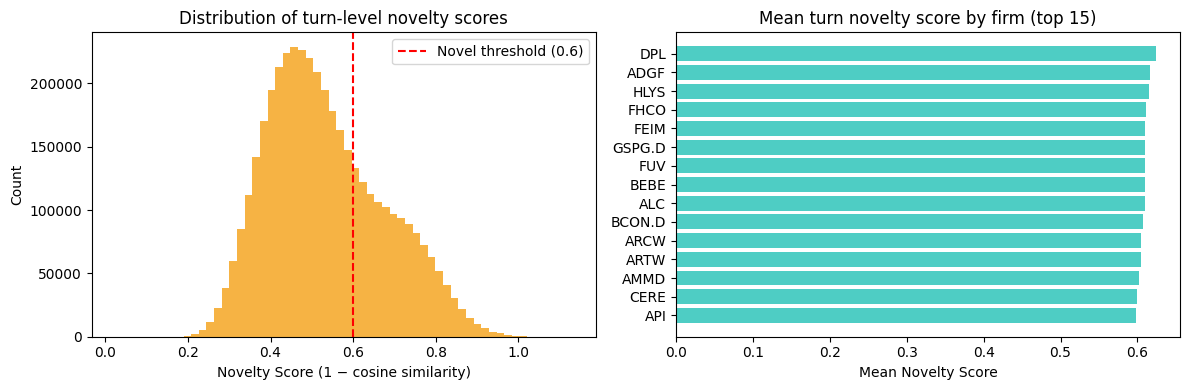

Saved novelty_distribution.png


In [15]:
import os
# Distribution of novelty scores
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall distribution
axes[0].hist(novelty_df["novelty_score"], bins=60, color="#f5a623", edgecolor="none", alpha=0.85)
axes[0].set_title("Distribution of turn-level novelty scores", fontsize=12)
axes[0].set_xlabel("Novelty Score (1 − cosine similarity)")
axes[0].set_ylabel("Count")
axes[0].axvline(0.6, color="red", linestyle="--", label="Novel threshold (0.6)")
axes[0].legend()

# By firm — top 15 highest mean *raw semantic novelty* (diagnostic; not impact-adjusted)
firm_avg = (novelty_df.groupby("ticker")["novelty_score"]
            .mean()
            .sort_values(ascending=False)
            .head(15))
axes[1].barh(firm_avg.index[::-1], firm_avg.values[::-1], color="#4ecdc4")
axes[1].set_title("Mean turn novelty score by firm (top 15)", fontsize=12)
axes[1].set_xlabel("Mean Novelty Score")

plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DATASET, "novelty_distribution.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved novelty_distribution.png")


## 4. Salience + LLM intent filter — PDF §3.3 Stage 1 (precision gate)

A high novelty score confirms the firm is discussing something *new* — but not whether it matters financially. A novel turn about litigation, regulatory disclosure, or a CEO aside would all score as novel.

We apply the **salience dictionary** to high-novelty **segments** (turn text in the `sentence` column) to verify that the novel content is a genuine business catalyst. The dictionary scores text across 26 financial clusters (guidance, earnings performance, revenue growth, new products, partnerships, etc.) — a strong proxy for the LLM binary intent filter described in the strategy paper.

**Ollama (local LLM)** uses the **verbatim YES/NO prompt** from **`project_specification_rio_zac.pdf`** §3.3 (financial materiality vs routine call language; exclusions for boilerplate and purely retrospective results). Cache stem: **`llm_intent_cache_project_spec_turns.pkl`** (sentence-split runs used `llm_intent_cache_project_spec.pkl`).

**Signal criteria:**
- `novelty_score ≥ 0.60` — semantically distant from firm's historical baseline
- `salience_score ≥ 0.30` — meaningful financial content, not boilerplate

**Ollama:** Start or restart the local API (default `127.0.0.1:11434`):

- **Terminal:** from `final_project`, run `bash scripts/ensure_ollama.sh`.
- **Notebook:** in the **next** code cell, set `ENSURE_OLLAMA = True` and run it once (it runs the same script via `subprocess`; kills the listener on `OLLAMA_PORT` then starts `ollama serve`). Leave `False` if the menu-bar app already serves the API.

Override with env vars `OLLAMA_HOST`, `OLLAMA_PORT`, or `OLLAMA_URL` if needed. Pull your model once: `ollama pull llama3.1` (or match `OLLAMA_MODEL`).


In [16]:
from huggingface_hub import login
login(token="YOUR_HF_TOKEN_HERE")

In [17]:
# ── Install & start vLLM on Google Colab ──────────────────────────────────────
# Requires a GPU runtime: Runtime → Change runtime type → GPU
# vLLM provides high-throughput batched inference with an OpenAI-compatible API.
# The model (~16 GB) is downloaded from HuggingFace to Colab's ephemeral disk.
# If the runtime resets you will need to re-run this cell.

import subprocess, time, requests

# 1. Install vLLM
print("Installing vLLM (this may take a few minutes)...")
!pip install -q vllm

# 2. Start vLLM server in the background
print(f"Starting vLLM server with model '{LLM_MODEL}'...")
print("(First run downloads the model from HuggingFace — may take several minutes)")

import os
env = os.environ.copy()
env["CUDA_VISIBLE_DEVICES"] = "0"

_vllm_proc = subprocess.Popen(
    [
        "python", "-m", "vllm.entrypoints.openai.api_server",
        "--model", LLM_MODEL,
        "--dtype", "auto",
        "--max-model-len", "4096",
        "--gpu-memory-utilization", "0.85",
    ],
    stdout=open("/tmp/vllm_stdout.log", "w"),
    stderr=open("/tmp/vllm_stderr.log", "w"),
    env=env,
)

# Wait for server to be ready (model download + loading can take a while)
print("Waiting for vLLM server to be ready...")
for i in range(600):  # up to 10 minutes
    try:
        r = requests.get(f"{LLM_BASE_URL}/models", timeout=2)
        if r.status_code == 200:
            break
    except Exception:
        pass
    if i % 15 == 14:
        print(f"  still loading... ({i+1}s)")
    time.sleep(1)
else:
    print("vLLM server did not start. Check /tmp/vllm_stderr.log:")
    !tail -20 /tmp/vllm_stderr.log
    raise RuntimeError("vLLM server failed to start within 10 minutes")

# 3. Verify
print("\n--- vLLM server check ---")
models = requests.get(f"{LLM_BASE_URL}/models").json()
print(f"Available models: {[m['id'] for m in models['data']]}")

# Quick test
_test = requests.post(f"{LLM_BASE_URL}/chat/completions", json={
    "model": LLM_MODEL, "messages": [{"role": "user", "content": "Say OK"}], "max_tokens": 3, "temperature": 0
}).json()
print(f"Test response: {_test['choices'][0]['message']['content'].strip()}")
print("vLLM setup complete.")

Installing vLLM (this may take a few minutes)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.1/433.1 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.7/267.7 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 137.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 128.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.9/635.9 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 14.9 MB/s eta 0:00

In [18]:
import time
import requests, json

# Config comes from the "Run configuration" cell near the top.
VLLM_CHAT_URL = f"{LLM_BASE_URL}/chat/completions"

print(f"vLLM API: {LLM_BASE_URL} | model: {LLM_MODEL}")

_llm_session = requests.Session()

# Thresholds match `project_specification_rio_zac.pdf` §3.3 Stage 1 (precision gate).
# (Defined in the Run configuration cell.)

# Cache stem tied to verbatim PDF prompt; bump filename if §3.3 prompt changes.
LLM_INTENT_CACHE = nh.dev_scoped_cache_path(Path("./pkl_cache/llm_intent_cache_project_spec_turns.pkl"), DEV_TICKERS)
if DEV_TICKERS:
    print(f"  LLM intent cache: {LLM_INTENT_CACHE.name}")

def _parse_llm_yes_no(raw: str) -> bool:
    """Parse YES/NO from model output (PDF asks for one word only)."""
    t = (raw or "").strip().upper()
    if not t:
        return False
    first_line = t.split("\n", 1)[0].strip()
    for tok in first_line.replace(",", " ").split():
        if tok.startswith("YES"):
            return True
        if tok.startswith("NO"):
            return False
    return False


def llm_intent_check(sentence: str, *, url: str | None = None) -> bool:
    """Verbatim prompt from `project_specification_rio_zac.pdf` §3.3; retries transient HTTP failures."""
    prompt = (
        f'You are a financial analyst reviewing a sentence from an earnings call transcript. Sentence: "{sentence}"\n\n'
        "Does this sentence contain information that is likely to be financially material and meaningfully different from "
        "routine earnings call language? This includes, but is not limited to, new strategic initiatives, product or service "
        "changes, partnerships, contracts, market expansion, pricing decisions, cost actions, management changes, "
        "capital allocation shifts, or any forward-looking statement that represents a departure from prior guidance or "
        "company narrative. Exclude only clear boilerplate (safe-harbour disclaimers, operator instructions, generic "
        "pleasantries) and retrospective descriptions of already-reported results with no forward-looking content. Reply "
        "with ONLY one word: YES or NO."
    )
    payload = {
        "model": LLM_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 10,
        "temperature": 0.0,
    }
    last_err = None
    for attempt in range(LLM_MAX_RETRIES):
        try:
            resp = _llm_session.post(url or VLLM_CHAT_URL, json=payload, timeout=LLM_HTTP_TIMEOUT)
            if resp.status_code >= 500:
                raise requests.HTTPError(f"HTTP {resp.status_code}")
            return _parse_llm_yes_no(resp.json()["choices"][0]["message"]["content"])
        except (requests.Timeout, requests.ConnectionError, requests.exceptions.ChunkedEncodingError) as e:
            last_err = e
        except (requests.HTTPError, KeyError, IndexError) as e:
            last_err = e
        except ValueError as e:
            last_err = e
        except Exception as e:
            print(f"vLLM non-retry error: {e}")
            return None  # None = failed
        wait = min(LLM_RETRY_MAX_SLEEP, LLM_RETRY_BASE_SEC * (2 ** attempt))
        print(f"vLLM retry {attempt + 1}/{LLM_MAX_RETRIES} ({last_err!r}); sleep {wait:.1f}s")
        time.sleep(wait)
    return None  # None = failed after all retries

# ── Load LLM cache ─────────────────────────────────────────────────────────────
if LLM_INTENT_CACHE.exists():
    with open(LLM_INTENT_CACHE, "rb") as f:
        intent_cache = pickle.load(f)
    print(f"Loaded {len(intent_cache):,} cached LLM results")
else:
    intent_cache = {}

# ── Step 1: salience filter on high-novelty segments ───────────────────────────
# We cache salience by (sentence, fiscal_year) so re-runs and kernel restarts don't recompute.
# This cache is **disk-backed** so you can stop/restart kernels without re-scoring.

SAL_CACHE_SAVE_EVERY = int(SAL_CACHE_SAVE_EVERY)  # new keys per checkpoint
SAL_CACHE_PATH = nh.dev_scoped_cache_path(
    Path("./pkl_cache/salience_cache_sentence_year.pkl"),
    DEV_TICKERS,
)
if DEV_TICKERS:
    print(f"  Salience cache: {SAL_CACHE_PATH.name}")

_SAL_CACHE: dict[tuple[str, int], tuple[float, str | None, str]]
if SAL_CACHE_PATH.exists():
    try:
        with open(SAL_CACHE_PATH, "rb") as f:
            _SAL_CACHE = pickle.load(f)
        print(f"Loaded {len(_SAL_CACHE):,} cached salience keys")
    except Exception as ex:
        print(f"Salience cache load failed ({ex}); starting empty")
        _SAL_CACHE = {}
else:
    _SAL_CACHE = {}

_sal_new_since_save = 0

def _save_sal_cache() -> None:
    if not SAL_CACHE_PATH.parent.exists():
        SAL_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(SAL_CACHE_PATH, "wb") as f:
        pickle.dump(_SAL_CACHE, f)


import multiprocessing as mp
from multiprocessing import Pool, cpu_count

# Match Rio notebook: use fork when available (macOS/Jupyter safety).
try:
    mp.set_start_method("fork")
except RuntimeError:
    pass

_sal_workers = SALIENCE_N_WORKERS
if _sal_workers is None or int(_sal_workers) <= 0:
    _sal_workers = max(1, cpu_count() - 1)
SALIENCE_N_WORKERS = int(_sal_workers)


def _sal_worker(item: tuple[str, int]) -> tuple[str, int, float, str | None, str]:
    sent, yr = item
    yr = int(yr)
    score, breakdown = score_sentence(str(sent), year=yr)
    top_cluster = max(breakdown, key=breakdown.get) if breakdown else None
    breakdown_json = json.dumps(breakdown)
    return (str(sent), yr, float(score), top_cluster, breakdown_json)


def _score_salience_rows(df_in: pd.DataFrame) -> pd.DataFrame:
    """Salience scoring with disk cache + multiprocessing for missing keys."""
    global _sal_new_since_save
    if df_in.empty:
        return df_in.copy()

    # Collect unique missing keys first (avoid recompute + enable Pool.imap).
    missing: list[tuple[str, int]] = []
    seen_missing: set[tuple[str, int]] = set()
    for _, row in df_in.iterrows():
        sent = str(row["sentence"])
        yr = int(row["fiscal_year"]) if pd.notna(row.get("fiscal_year")) else 2020
        key = (sent, int(yr))
        if key in _SAL_CACHE:
            continue
        if key not in seen_missing:
            seen_missing.add(key)
            missing.append(key)

    if missing:
        print(f"  salience: computing {len(missing):,} new keys with {SALIENCE_N_WORKERS} workers...")
        from tqdm.auto import tqdm
        with Pool(SALIENCE_N_WORKERS) as _pool:
            for sent, yr, score, top_cluster, breakdown_json in tqdm(_pool.imap(_sal_worker, missing, chunksize=50), total=len(missing), desc="Salience scoring"):
                _SAL_CACHE[(sent, int(yr))] = (float(score), top_cluster, breakdown_json)
                _sal_new_since_save += 1
                if _sal_new_since_save >= SAL_CACHE_SAVE_EVERY:
                    _save_sal_cache()
                    print(f"  salience checkpoint: {len(_SAL_CACHE):,} keys → {SAL_CACHE_PATH.name}")
                    _sal_new_since_save = 0

    # Build output aligned to df_in order.
    out: list[dict] = []
    for _, row in df_in.iterrows():
        sent = str(row["sentence"])
        yr = int(row["fiscal_year"]) if pd.notna(row.get("fiscal_year")) else 2020
        score, top_cluster, breakdown_json = _SAL_CACHE[(sent, int(yr))]
        out.append(
            {
                "salience_score": float(score),
                "top_cluster": top_cluster,
                "cluster_breakdown": breakdown_json,
            }
        )

    if _sal_new_since_save:
        _save_sal_cache()
        print(f"  salience cache saved: {len(_SAL_CACHE):,} keys → {SAL_CACHE_PATH.name}")
        _sal_new_since_save = 0

    sal_df = pd.DataFrame(out)
    return pd.concat([df_in.reset_index(drop=True), sal_df.reset_index(drop=True)], axis=1)


def _build_signal_df(novelty_df_in: pd.DataFrame, *, label: str) -> pd.DataFrame:
    high = novelty_df_in[novelty_df_in["novelty_score"] >= NOVELTY_THRESHOLD].copy()
    print(f"[{label}] High-novelty segments: {len(high):,}")
    if high.empty:
        return high
    print(f"[{label}] Scoring salience...")
    scored = _score_salience_rows(high)
    scored = scored[scored["salience_score"] >= SALIENCE_THRESHOLD].copy()
    print(f"[{label}] After salience filter: {len(scored):,} segments")
    return scored


def _print_top10(df_in: pd.DataFrame, *, label: str) -> None:
    if df_in is None or df_in.empty:
        print(f"\n=== Top 10 ({label}) — EMPTY ===\n")
        return
    _tmp = df_in.copy()
    # Pre-impact diagnostic ranking: novelty × √salience (macro + impact are applied later).
    _tmp["adj_preimpact_no_macro"] = _tmp["novelty_score"].astype(float) * np.sqrt(_tmp["salience_score"].astype(float))
    top = _tmp.sort_values(["adj_preimpact_no_macro", "novelty_score"], ascending=False).head(10)
    print(f"\n=== Top 10 Highest (novelty × √salience) Segments ({label}) ===\n")
    for _, r in top.iterrows():
        print(f"Ticker : {r['ticker']} | Quarter: {r['quarter_str']} | Transcript: {int(r['transcriptid'])} | Chunk: {int(r['chunk_index'])}")
        print(f"Novelty: {r['novelty_score']:.3f}  |  Salience: {r['salience_score']:.3f}  |  Novelty×√Salience: {r['adj_preimpact_no_macro']:.4f}  |  Cluster: {r['top_cluster']}")
        print(f"Text : {str(r['sentence'])[:4000]}")
        print("")

signal_df = _build_signal_df(novelty_df, label=NOVELTY_PRIMARY_MODE)
_print_top10(signal_df, label=NOVELTY_PRIMARY_MODE)

# Merge rolling analyst attention onto each (call, cluster) with no lookahead.
# `analyst_roll` is built earlier from raw_turn_df (Analysts only) over trailing 90 days.
if 'analyst_roll' in globals() and len(analyst_roll):
    signal_df = signal_df.merge(
        analyst_roll,
        on=['transcriptid','top_cluster'],
        how='left',
        validate='many_to_one',
    )
else:
    signal_df['trailing_unique_analysts_90d'] = np.nan
signal_df['trailing_unique_analysts_90d'] = signal_df['trailing_unique_analysts_90d'].fillna(0).astype(int)
print(f"After salience filter: {len(signal_df):,} segments")

# ── Step 2: LLM intent filter (PDF §3.3 Stage 1 — all rows that passed novelty≥0.60 & salience≥0.30)
llm_candidates = signal_df.copy()

print(f"Sending {len(llm_candidates):,} segments to vLLM (spec precision gate)...")
print(
    f"  timeout={LLM_HTTP_TIMEOUT}s retries={LLM_MAX_RETRIES} save_every={LLM_CACHE_SAVE_EVERY} new answers"
)

from concurrent.futures import ThreadPoolExecutor, as_completed

sent_list = llm_candidates["sentence"].astype(str).tolist()
missing = [s for s in sent_list if s not in intent_cache]
missing_unique = list(dict.fromkeys(missing))

_intent_workers = LLM_MAX_WORKERS
if _intent_workers is None or int(_intent_workers) <= 0:
    _intent_workers = 16
LLM_MAX_WORKERS = int(_intent_workers)

if missing_unique:
    print(f"  LLM intent: {len(missing_unique):,} new sentences ({LLM_MAX_WORKERS} workers)")
    _new_since_save = 0
    _done = 0
    try:
        with ThreadPoolExecutor(max_workers=LLM_MAX_WORKERS) as ex:
            futs = {}
            for j, s in enumerate(missing_unique):
                futs[ex.submit(llm_intent_check, s)] = s

            from tqdm.auto import tqdm
            for fut in tqdm(as_completed(futs), total=len(futs), desc="LLM intent"):
                s = futs[fut]
                result = fut.result()
                if result is None:
                    intent_cache[s] = None  # flag as failed
                else:
                    intent_cache[s] = bool(result)
                _new_since_save += 1
                _done += 1
                if _new_since_save >= LLM_CACHE_SAVE_EVERY:
                    with open(LLM_INTENT_CACHE, "wb") as f:
                        pickle.dump(intent_cache, f)
                    _new_since_save = 0
    finally:
        with open(LLM_INTENT_CACHE, "wb") as f:
            pickle.dump(intent_cache, f)
        _n_failed = sum(1 for v in intent_cache.values() if v is None)
        print(f"Cache saved: {len(intent_cache):,} keys ({_n_failed:,} failed) \u2192 {LLM_INTENT_CACHE.name}")

    # ── Retry pass: reprocess failed (None) entries with fewer workers ──
    _failed_sents = [s for s, v in intent_cache.items() if v is None]
    if _failed_sents:
        print(f"\n  Retry pass: {len(_failed_sents):,} failed sentences (2 workers, 2 retries)...")
        _retry_new = 0
        _saved_retries, LLM_MAX_RETRIES = LLM_MAX_RETRIES, 2
        _saved_sleep, LLM_RETRY_MAX_SLEEP = LLM_RETRY_MAX_SLEEP, 30.0
        with ThreadPoolExecutor(max_workers=2) as ex:
            futs = {ex.submit(llm_intent_check, s): s for s in _failed_sents}
            for fut in tqdm(as_completed(futs), total=len(futs), desc="LLM intent retry"):
                s = futs[fut]
                result = fut.result()
                if result is not None:
                    intent_cache[s] = bool(result)
                    _retry_new += 1
        LLM_MAX_RETRIES, LLM_RETRY_MAX_SLEEP = _saved_retries, _saved_sleep
        with open(LLM_INTENT_CACHE, "wb") as f:
            pickle.dump(intent_cache, f)
        _still_failed = sum(1 for v in intent_cache.values() if v is None)
        print(f"  Retry recovered {_retry_new:,} / {len(_failed_sents):,} | still failed: {_still_failed:,}")
        if _still_failed:
            print(f"  WARNING: {_still_failed:,} sentences permanently failed \u2014 treated as NO")
            for s in list(intent_cache):
                if intent_cache[s] is None:
                    intent_cache[s] = False
            with open(LLM_INTENT_CACHE, "wb") as f:
                pickle.dump(intent_cache, f)
else:
    _nu = len(dict.fromkeys(sent_list))
    print(
        f"  LLM intent: 0 new sentences ({len(sent_list):,} candidate rows, {_nu:,} unique texts already in disk cache). "
        "If you expanded the ticker panel, re-run the novelty cell so new transcripts are scored, then re-run this cell."
    )

llm_candidates["llm_intent_pass"] = [bool(intent_cache.get(s, False)) for s in sent_list]

signal_df = llm_candidates[llm_candidates["llm_intent_pass"] == True].copy()

print(f"After LLM intent filter: {len(signal_df):,} segments")
print(f"LLM pass rate: {llm_candidates['llm_intent_pass'].mean():.1%}")


# ── Memory cleanup ──
import gc
del _SAL_CACHE
try:
    del novelty_df
except NameError:
    pass
gc.collect()
print("Freed salience cache and novelty_df from memory.")

vLLM API: http://127.0.0.1:8000/v1 | model: meta-llama/Meta-Llama-3.1-8B-Instruct
Loaded 222,036 cached LLM results
Loaded 1,154,418 cached salience keys
[full_turns] High-novelty segments: 1,229,817
[full_turns] Scoring salience...
[full_turns] After salience filter: 223,061 segments

=== Top 10 Highest (novelty × √salience) Segments (full_turns) ===

Ticker : ADSK | Quarter: 2024Q2 | Transcript: 3157579 | Chunk: 2
Novelty: 0.707  |  Salience: 294.492  |  Novelty×√Salience: 12.1254  |  Cluster: technology_digital
Text : Thank you, Simon, and welcome, everyone, to the call. As I'm sure you can appreciate with legal matters like this, I'm restricted in what I can say regarding the Audit Committee investigation, but let me say what I can. The summary findings of the Audit Committee investigation are in our May 31 press release and recently filed Form 10-K. Please refer to those documents for details. We don't have further commentary beyond what we have described there. Regarding the proc

In [19]:
# ── LLM Stage 2: directional impact score (−1 … +1) for intent-passed segments ──
# Run **after** the intent gate cell above has set `signal_df` (LLM YES rows only).
# Uses the same Ollama endpoint/model/timeouts as Stage 1. Results are **pickle-cached**
# by transcript sentence string (resume-safe; bump filename if you change the prompt).

import pickle
import re
from pathlib import Path

LLM_IMPACT_CACHE = nh.dev_scoped_cache_path(
    Path("./pkl_cache/llm_impact_score_project_spec_turns.pkl"),
    DEV_TICKERS,
)
IMPACT_CACHE_SAVE_EVERY = int(IMPACT_CACHE_SAVE_EVERY)

if DEV_TICKERS:
    print(f"  LLM impact cache: {LLM_IMPACT_CACHE.name}")


def _parse_impact_scalar(raw: str) -> float:
    """Extract a single number from model output; clip to [-1, 1]. NaN if none."""
    t = (raw or "").strip()
    if not t:
        return float("nan")
    first = t.split("\n", 1)[0].strip()
    m = re.search(r"[-+]?\d+(?:\.\d+)?(?:e[-+]?\d+)?", first, re.I)
    if not m:
        return float("nan")
    x = float(m.group(0))
    return float(max(-1.0, min(1.0, x)))


def llm_impact_score(sentence: str, *, url: str | None = None) -> float:
    """
    Same analyst framing as §3.3 intent gate, but output is one real in [-1, 1]:
    expected directional implication for near-term shareholder value / stock reaction
    attributable to this passage alone (not the whole call). Retries on transient HTTP errors.
    """
    prompt = (
        f'You are a financial analyst reviewing a passage from an earnings call transcript. Passage: "{sentence}"\n\n'
        "You already determined this passage is materially non-routine (Stage 1). "
        "Now score the **expected directional impact** on the stock over the next several trading sessions "
        "that a rational investor would infer **from this passage alone** — "
        "negative if it worsens the outlook (e.g. cuts, delays, adverse regulation, major demand weakness), "
        "positive if it improves it (e.g. strong demand, major new revenue driver, favorable resolution), "
        "and near zero if ambiguous or purely descriptive.\n\n"
        "Reply with **ONLY** one number between -1 and +1 (inclusive). "
        "Use two decimals if helpful. Do not add words, labels, or punctuation."
    )
    payload = {
        "model": LLM_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": 8,
        "temperature": 0.0,
    }
    last_err = None
    for attempt in range(LLM_MAX_RETRIES):
        try:
            resp = _llm_session.post(url or VLLM_CHAT_URL, json=payload, timeout=LLM_HTTP_TIMEOUT)
            if resp.status_code >= 500:
                raise requests.HTTPError(f"HTTP {resp.status_code}")
            v = _parse_impact_scalar(resp.json()["choices"][0]["message"]["content"])
            if v != v:  # NaN
                raise ValueError("unparseable impact score")
            return v
        except (requests.Timeout, requests.ConnectionError, requests.exceptions.ChunkedEncodingError) as e:
            last_err = e
        except (requests.HTTPError, KeyError, IndexError) as e:
            last_err = e
        except ValueError as e:
            last_err = e
        except Exception as e:
            print(f"vLLM impact non-retry error: {e}")
            return None  # None = failed
        wait = min(LLM_RETRY_MAX_SLEEP, LLM_RETRY_BASE_SEC * (2**attempt))
        print(f"vLLM impact retry {attempt + 1}/{LLM_MAX_RETRIES} ({last_err!r}); sleep {wait:.1f}s")
        time.sleep(wait)
    return None  # None = failed after all retries


if "signal_df" not in globals() or signal_df is None or len(signal_df) == 0:
    raise RuntimeError("signal_df is empty or undefined — run the intent-gate cell first.")

if LLM_IMPACT_CACHE.exists():
    with open(LLM_IMPACT_CACHE, "rb") as f:
        impact_cache = pickle.load(f)
    print(f"Loaded {len(impact_cache):,} cached impact scores")
else:
    impact_cache = {}

from concurrent.futures import ThreadPoolExecutor, as_completed

sent_list = signal_df["sentence"].astype(str).tolist()
missing = [s for s in sent_list if s not in impact_cache]
missing_unique = list(dict.fromkeys(missing))

_impact_workers = LLM_IMPACT_WORKERS
if _impact_workers is None or int(_impact_workers) <= 0:
    _impact_workers = 16
LLM_IMPACT_WORKERS = int(_impact_workers)

if missing_unique:
    print(f"  LLM impact: {len(missing_unique):,} new sentences ({LLM_IMPACT_WORKERS} workers)")
    _impact_new = 0
    _done = 0
    try:
        with ThreadPoolExecutor(max_workers=LLM_IMPACT_WORKERS) as ex:
            futs = {}
            for j, s in enumerate(missing_unique):
                futs[ex.submit(llm_impact_score, s)] = s
            from tqdm.auto import tqdm
            for fut in tqdm(as_completed(futs), total=len(futs), desc="LLM impact"):
                s = futs[fut]
                result = fut.result()
                if result is None:
                    impact_cache[s] = None  # flag as failed
                else:
                    impact_cache[s] = float(result)
                _impact_new += 1
                _done += 1
                if _impact_new >= IMPACT_CACHE_SAVE_EVERY:
                    with open(LLM_IMPACT_CACHE, "wb") as f:
                        pickle.dump(impact_cache, f)
                    _impact_new = 0
    finally:
        with open(LLM_IMPACT_CACHE, "wb") as f:
            pickle.dump(impact_cache, f)
        _n_failed = sum(1 for v in impact_cache.values() if v is None)
        print(f"Impact cache saved: {len(impact_cache):,} keys ({_n_failed:,} failed) → {LLM_IMPACT_CACHE.name}")

    # ── Retry pass: reprocess failed (None) entries with fewer workers ──
    _failed_sents = [s for s, v in impact_cache.items() if v is None]
    if _failed_sents:
        print(f"\n  Retry pass: {len(_failed_sents):,} failed sentences (2 workers, 2 retries)...")
        _retry_new = 0
        _saved_retries, LLM_MAX_RETRIES = LLM_MAX_RETRIES, 2
        _saved_sleep, LLM_RETRY_MAX_SLEEP = LLM_RETRY_MAX_SLEEP, 30.0
        with ThreadPoolExecutor(max_workers=2) as ex:
            futs = {ex.submit(llm_impact_score, s): s for s in _failed_sents}
            for fut in tqdm(as_completed(futs), total=len(futs), desc="LLM impact retry"):
                s = futs[fut]
                result = fut.result()
                if result is not None:
                    impact_cache[s] = float(result)
                    _retry_new += 1
        LLM_MAX_RETRIES, LLM_RETRY_MAX_SLEEP = _saved_retries, _saved_sleep
        with open(LLM_IMPACT_CACHE, "wb") as f:
            pickle.dump(impact_cache, f)
        _still_failed = sum(1 for v in impact_cache.values() if v is None)
        print(f"  Retry recovered {_retry_new:,} / {len(_failed_sents):,} | still failed: {_still_failed:,}")
        if _still_failed:
            print(f"  WARNING: {_still_failed:,} sentences permanently failed — treated as 0.0")
            for s in list(impact_cache):
                if impact_cache[s] is None:
                    impact_cache[s] = 0.0
            with open(LLM_IMPACT_CACHE, "wb") as f:
                pickle.dump(impact_cache, f)

_impact_vals = [float(impact_cache.get(s, 0.0) or 0.0) for s in sent_list]

signal_df = signal_df.copy()
signal_df["llm_impact_score"] = _impact_vals
print(signal_df["llm_impact_score"].describe().round(3))
# If you re-run the cache-only intent cell later, it rebuilds `signal_df` without this column — re-run this cell to re-attach.


# ── Memory cleanup ──
import gc
del impact_cache
gc.collect()
print("Freed impact_cache from memory.")

Loaded 156,629 cached impact scores
count    156856.000
mean         -0.117
std           0.313
min          -0.990
25%          -0.400
50%           0.000
75%           0.000
max           0.990
Name: llm_impact_score, dtype: float64
Freed impact_cache from memory.


Segments with impact + overnight + salience + novelty: 156,855


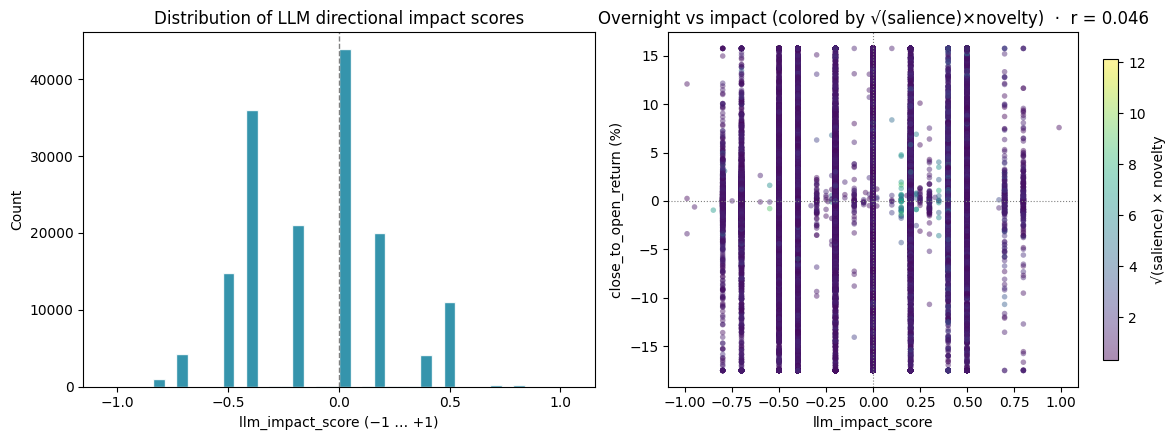

In [20]:
import os
# ── LLM impact score: distribution + vs overnight return ─────────────────────
# Prefers `signal_df["llm_impact_score"]` from Stage 2; if missing (e.g. you re-ran the
# cache-only intent cell), loads scores from the same pickle as Stage 2.

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

if "llm_impact_score" not in signal_df.columns:
    _impact_pkl = nh.dev_scoped_cache_path(
        Path("./pkl_cache/llm_impact_score_project_spec_turns.pkl"),
        DEV_TICKERS,
    )
    if not _impact_pkl.is_file():
        raise RuntimeError(
            f"`llm_impact_score` not on signal_df and no cache file at {_impact_pkl}. "
            "Run the LLM Stage 2 (impact) cell first."
        )
    with open(_impact_pkl, "rb") as f:
        _idc = pickle.load(f)
    signal_df = signal_df.copy()
    signal_df["llm_impact_score"] = signal_df["sentence"].map(lambda s: _idc.get(s))
    print(
        f"Attached llm_impact_score from {_impact_pkl.name} "
        f"({len(_idc):,} keys in pickle)"
    )

if "close_to_open_return" not in signal_df.columns:
    raise RuntimeError(
        "signal_df has no close_to_open_return — ensure novelty records / merge included it."
    )

_imp = signal_df.dropna(
    subset=[
        "llm_impact_score",
        "close_to_open_return",
        "salience_score",
        "novelty_score",
    ]
).copy()
print(f"Segments with impact + overnight + salience + novelty: {len(_imp):,}")
if _imp.empty:
    raise RuntimeError(
        "No rows with non-null llm_impact_score, close_to_open_return, salience_score, novelty_score. "
        "Re-run Stage 2 impact scoring or check sentence keys vs impact pickle."
    )

_color = np.sqrt(_imp["salience_score"].clip(lower=0)) * _imp["novelty_score"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.hist(_imp["llm_impact_score"], bins=40, range=(-1.05, 1.05), color="#1985A1", edgecolor="white", alpha=0.88)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("llm_impact_score (−1 … +1)")
ax.set_ylabel("Count")
ax.set_title("Distribution of LLM directional impact scores")

ax = axes[1]
sc = ax.scatter(
    _imp["llm_impact_score"],
    _imp["close_to_open_return"] * 100.0,
    alpha=0.45,
    s=16,
    c=_color,
    cmap="viridis",
    edgecolors="none",
)
ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.axvline(0, color="gray", ls=":", lw=0.8)
ax.set_xlabel("llm_impact_score")
ax.set_ylabel("close_to_open_return (%)")
if len(_imp) >= 3:
    r = _imp["llm_impact_score"].corr(_imp["close_to_open_return"])
    ax.set_title(f"Overnight vs impact (colored by √(salience)×novelty)  ·  r = {r:.3f}")
else:
    ax.set_title("Overnight vs impact (colored by √(salience)×novelty)")
plt.colorbar(sc, ax=ax, shrink=0.85, label="√(salience) × novelty")

plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DATASET, "llm_impact_vs_overnight.png"), dpi=150, bbox_inches="tight")
plt.show()


In [21]:
import os
signal_df
signal_df.to_csv(os.path.join(GDRIVE_DATASET, "signal_df.csv"))

In [22]:
# ── Apply LLM gate from disk cache only (resume-safe) ─────────────────────────
# Run this if you **stopped the LLM loop early**: the prior cell's `finally` saves
# `intent_cache` to `LLM_INTENT_CACHE`, but `signal_df` is only LLM-filtered after
# the loop assigns `llm_intent_pass`. This cell **reloads the pickle** and rebuilds
# `llm_candidates["llm_intent_pass"]` from cached YES/NO only (no Ollama calls).
#
# Rows whose `sentence` is **not** in the cache are treated as **NO** (excluded).
# Re-run the main LLM cell later to fill gaps; cached keys are skipped on API.

if "LLM_INTENT_CACHE" not in globals():
    raise RuntimeError("Run the Ollama / LLM cell above first (defines LLM_INTENT_CACHE).")

if "llm_candidates" not in globals() or llm_candidates is None or len(llm_candidates) == 0:
    raise RuntimeError(
        "Define llm_candidates first (run the main cell through "
        "`llm_candidates = signal_df.copy()`)."
    )

if LLM_INTENT_CACHE.exists():
    with open(LLM_INTENT_CACHE, "rb") as f:
        _ic_disk = pickle.load(f)
else:
    _ic_disk = {}

_missing = 0
_llm_flags: list[bool] = []
for _, _row in llm_candidates.iterrows():
    _s = _row["sentence"]
    if _s in _ic_disk:
        _llm_flags.append(bool(_ic_disk[_s]))
    else:
        _missing += 1
        _llm_flags.append(False)

llm_candidates = llm_candidates.copy()
llm_candidates["llm_intent_pass"] = _llm_flags
intent_cache = dict(_ic_disk)

_n_keys = len(_ic_disk)
print(
    f"Cache-only gate: {_n_keys:,} keys on disk | "
    f"{len(llm_candidates) - _missing:,} rows with cached LLM | "
    f"{_missing:,} rows missing from cache (treated as NO)"
)
signal_df = llm_candidates[llm_candidates["llm_intent_pass"]].copy()

# If impact scores have been computed before, keep them attached on resume runs.
if "llm_impact_score" not in signal_df.columns:
    _impact_pkl = nh.dev_scoped_cache_path(
        Path("./pkl_cache/llm_impact_score_project_spec_turns.pkl"),
        DEV_TICKERS,
    )
    if _impact_pkl.is_file():
        with open(_impact_pkl, "rb") as f:
            _impact_disk = pickle.load(f)
        signal_df["llm_impact_score"] = signal_df["sentence"].map(lambda s: _impact_disk.get(s))
        print(f"Re-attached llm_impact_score from {_impact_pkl.name} ({len(_impact_disk):,} keys)")

print(f"After LLM gate (cache-only): {len(signal_df):,} segments")
if len(llm_candidates):
    print(f"LLM pass rate (on llm_candidates): {llm_candidates['llm_intent_pass'].mean():.1%}")


Cache-only gate: 222,036 keys on disk | 223,061 rows with cached LLM | 0 rows missing from cache (treated as NO)
Re-attached llm_impact_score from llm_impact_score_project_spec_turns.pkl (156,629 keys)
After LLM gate (cache-only): 156,856 segments
LLM pass rate (on llm_candidates): 70.3%


In [23]:
signal_df = llm_candidates[llm_candidates["llm_intent_pass"] == True].copy()

print(f"After LLM intent filter: {len(signal_df):,} segments")
print(f"LLM pass rate: {llm_candidates['llm_intent_pass'].mean():.1%}")

After LLM intent filter: 156,856 segments
LLM pass rate: 70.3%


In [24]:
# ── Rebuild chunk_to_component.csv from full signal_df (before Q&A filter) ────
# This must run BEFORE the Q&A-only filter cell so the mapping covers all segments.

chunk_to_component = build_chunk_to_component_for_signal_df(signal_df, raw_turn_df, exec_chunks)

_cols = [
    "novelty_mode",
    "transcriptid",
    "chunk_index",
    "exec_turn_index",
    "componentorder",
    "transcriptcomponentid",
    "speakertypename",
]
for c in _cols:
    if c not in chunk_to_component.columns:
        chunk_to_component[c] = np.nan

chunk_to_component[_cols].to_csv(os.path.join(GDRIVE_DATASET, "chunk_to_component.csv"), index=False)

print(f"chunk_to_component rows: {len(chunk_to_component):,}")
print(f"Unique transcripts: {chunk_to_component['transcriptid'].nunique():,}")
print(f"→ wrote chunk_to_component.csv (run Q&A filter cell next)")

chunk_to_component rows: 156,856
Unique transcripts: 57,422
→ wrote chunk_to_component.csv (run Q&A filter cell next)


In [25]:
# ── Optional filter: keep only Q&A (after first "question" component) ─────────
# Cache-only: uses speaker_indices + chunk_to_component.csv (no re-embedding / no LLM).

from pathlib import Path

USE_QA_ONLY = True  # set False to keep prepared remarks too

if USE_QA_ONLY:
    SPEAKER_INDICES_CSV = _PROJECT_ROOT / "transcript_speaker_indices.csv"
    CHUNK_TO_COMPONENT_CSV = Path(os.path.join(GDRIVE_DATASET, "chunk_to_component.csv"))

    if not CHUNK_TO_COMPONENT_CSV.is_file():
        raise FileNotFoundError(
            f"Missing {CHUNK_TO_COMPONENT_CSV}. Run the chunk_index→componentorder export cell first."
        )

    # 1) First componentorder with typename containing "question" (per transcript)
    usecols = ["transcriptid", "componentorder", "transcriptcomponenttypename"]
    q_min: dict[int, int] = {}

    for chunk in pd.read_csv(SPEAKER_INDICES_CSV, usecols=usecols, chunksize=500_000, low_memory=False):
        chunk = chunk.dropna(subset=["transcriptid", "componentorder", "transcriptcomponenttypename"]).copy()
        chunk["transcriptid"] = pd.to_numeric(chunk["transcriptid"], errors="coerce").astype("Int64")
        chunk["componentorder"] = pd.to_numeric(chunk["componentorder"], errors="coerce").astype("Int64")
        t = chunk["transcriptcomponenttypename"].astype(str).str.lower()
        is_q = t.str.contains("question", regex=False)
        sub = chunk.loc[is_q, ["transcriptid", "componentorder"]].dropna()
        if sub.empty:
            continue
        # min componentorder per transcript in this chunk
        grp = sub.groupby("transcriptid", sort=False)["componentorder"].min()
        for tid, co in grp.items():
            tid_i = int(tid)
            co_i = int(co)
            prev = q_min.get(tid_i)
            if prev is None or co_i < prev:
                q_min[tid_i] = co_i

    speaker_question_start = pd.DataFrame(
        {"transcriptid": list(q_min.keys()), "question_componentorder": list(q_min.values())}
    )

    # 2) Filter chunk_to_component to those AFTER the first question component
    chunk_to_component = pd.read_csv(CHUNK_TO_COMPONENT_CSV)
    chunk_to_component["transcriptid"] = pd.to_numeric(chunk_to_component["transcriptid"], errors="coerce").astype("Int64")
    chunk_to_component["chunk_index"] = pd.to_numeric(chunk_to_component["chunk_index"], errors="coerce").astype("Int64")
    chunk_to_component["componentorder"] = pd.to_numeric(chunk_to_component.get("componentorder"), errors="coerce").astype("Int64")

    filt_signal = (
        chunk_to_component.merge(speaker_question_start, on="transcriptid", how="left")
        .dropna(subset=["componentorder", "question_componentorder"])
        .query("componentorder > question_componentorder")
        [["transcriptid", "chunk_index"]]
        .drop_duplicates()
        .rename(columns={"chunk_index": "chunk_index"})
    )

    # 3) Apply to signal_df
    _n0 = len(signal_df)
    signal_df = signal_df.merge(filt_signal, on=["transcriptid", "chunk_index"], how="inner")
    print(
        f"Q&A-only filter: kept {len(signal_df):,} / {_n0:,} segments "
        f"({len(signal_df) / max(_n0, 1):.1%})."
    )
    print(f"  transcripts with a detected question component: {len(speaker_question_start):,}")

    # Optional quick check like your R snippet
    # print(signal_df.sort_values('adjusted_novelty').head(3)[['ticker','transcriptid','chunk_index','sentence']].to_string(index=False))


Q&A-only filter: kept 152,509 / 156,856 segments (97.2%).
  transcripts with a detected question component: 176,826


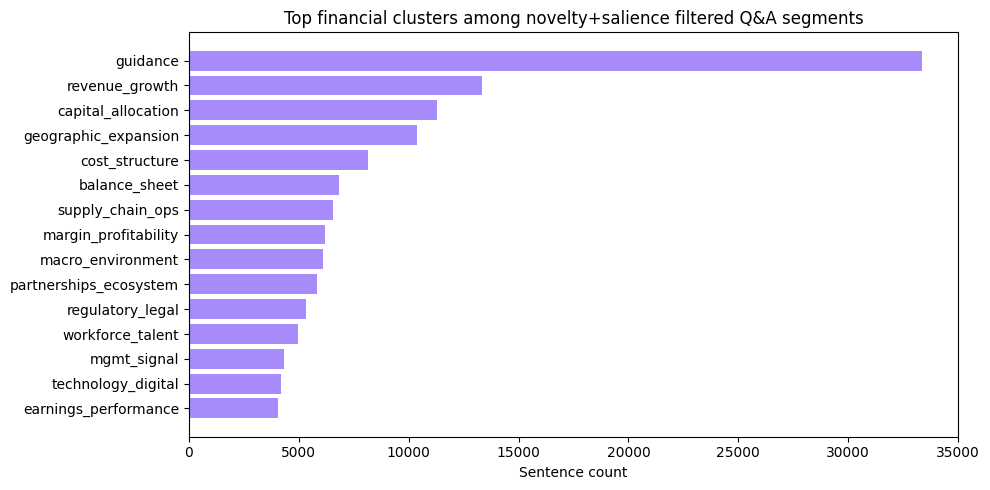


Top 10 clusters among novelty+salience filtered Q&A segments:
top_cluster
guidance                  33336
revenue_growth            13328
capital_allocation        11287
geographic_expansion      10369
cost_structure             8129
balance_sheet              6854
supply_chain_ops           6564
margin_profitability       6196
macro_environment          6110
partnerships_ecosystem     5812


In [26]:
import os
# What clusters dominate novel sentences?
cluster_counts = (signal_df["top_cluster"]
                  .value_counts()
                  .head(15))

plt.figure(figsize=(10, 5))
plt.barh(cluster_counts.index[::-1], cluster_counts.values[::-1], color="#a78bfa")
plt.title("Top financial clusters among novelty+salience filtered Q&A segments", fontsize=12)
plt.xlabel("Sentence count")
plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DATASET, "cluster_distribution.png"), dpi=120, bbox_inches="tight")
plt.show()

print("\nTop 10 clusters among novelty+salience filtered Q&A segments:")
print(cluster_counts.head(10).to_string())


In [27]:
# Example: highest novelty × √salience segments (pre-impact; macro/impact applied later)
print("=== Top 10 Highest (novelty × √salience) Segments (pre-impact) ===\n")
_tmp = signal_df.copy()
_tmp["adj_preimpact_no_macro"] = _tmp["novelty_score"].astype(float) * np.sqrt(_tmp["salience_score"].astype(float))
top_examples = (_tmp
                .sort_values(["adj_preimpact_no_macro", "novelty_score"], ascending=False)
                .head(10))

for _, row in top_examples.iterrows():
    tid = int(row['transcriptid'])
    ci = int(row.get('chunk_index', -1)) if pd.notna(row.get('chunk_index', np.nan)) else -1
    print(f"Ticker : {row['ticker']}  |  Quarter: {row['quarter_str']} | Transcript: {tid} | Chunk: {ci}")
    print(f"Novelty: {row['novelty_score']:.3f}  |  Salience: {row['salience_score']:.3f}  |  Novelty×√Salience: {row['adj_preimpact_no_macro']:.4f}  |  Cluster: {row['top_cluster']}")

    # Show chunk parts (context + exec) when available; else fall back to the stored segment text.
    ctx = ''
    ex = ''
    if ci >= 0:
        ctx_list = CONTEXT_TEXT_BY_TID.get(tid)
        ex_list = EXEC_TEXT_BY_TID.get(tid)
        if isinstance(ctx_list, list) and ci < len(ctx_list):
            ctx = str(ctx_list[ci])
        if isinstance(ex_list, list) and ci < len(ex_list):
            ex = str(ex_list[ci])

    if ctx or ex:
        if ctx:
            print(f"Context: {ctx[:400]}...")
        if ex:
            print(f"Exec   : {ex[:400]}...")
    else:
        print(f"Text   : {str(row['sentence'])[:800]}...")
    print()


=== Top 10 Highest (novelty × √salience) Segments (pre-impact) ===

Ticker : ANSS  |  Quarter: 2022Q1 | Transcript: 2505311 | Chunk: 14
Novelty: 0.775  |  Salience: 51.948  |  Novelty×√Salience: 5.5882  |  Cluster: technology_digital
Context: That makes sense. Nicole, maybe for my follow-up for you. I actually missed what you said earlier just on the organic constant currency ACV growth in 2021. Could you just recap that for us? And as part of that, can you just remind us how much ZMAX is adding in -- or maybe just broadly, what the organic constant currency ACV growth is assumed in the 2022 guide?...
Exec   : Sure. Yes, apologies. I had some technical difficulties earlier, so I apologize for those who couldn't hear my answer. Yes. So for both the fourth quarter and full year 2021, our ACV growth in constant currency was 16%. And when you back out the $86 million to $88 million associated with the combination of AGI and ZMAX, you can see that's really strong organic growth, both in the

In [28]:
signal_df

,ticker,quarter_str,fiscal_year,transcriptid,close_to_open_return,sentence,chunk_index,novelty_score,cosine_sim,novelty_mode,salience_score,top_cluster,cluster_breakdown,trailing_unique_analysts_90d,llm_intent_pass
0,096944426,2011Q1,2011,104195.0,0.015823,quick questions you guys mentioned the embedde...,7,0.674313,0.325687,full_turns,2.70,balance_sheet,"{""guidance"": 0.0, ""earnings_performance"": 0.0,...",244,True
1,096944426,2011Q1,2011,104195.0,0.015823,there are being introduced into the other EU c...,14,0.614577,0.385423,full_turns,1.50,guidance,"{""guidance"": 1.5, ""earnings_performance"": 0.0,...",2331,True
2,096944426,2011Q1,2011,104195.0,0.015823,into Silicon that’s going to take a while and ...,21,0.631437,0.368563,full_turns,5.93,guidance,"{""guidance"": 3.0, ""earnings_performance"": 0.0,...",2331,True
3,096944426,2011Q1,2011,104195.0,0.015823,by Intel and by VASCO to the OEMs of Intel tho...,23,0.660650,0.339350,full_turns,5.36,technology_digital,"{""guidance"": 1.5, ""earnings_performance"": 0.0,...",0,True
4,096944426,2011Q1,2011,104195.0,0.015823,secure the transactions between their customer...,25,0.693135,0.306865,full_turns,2.49,technology_digital,"{""guidance"": 0.0, ""earnings_performance"": 0.0,...",0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152504,KRUS,2024Q3,2024,3183818.0,-0.041731,"Okay, understood. And then just one last quick...",66,0.635203,0.364797,full_turns,1.08,supply_chain_ops,"{""guidance"": 0.0, ""earnings_performance"": 0.0,...",356,True
152505,KRUS,2024Q3,2024,3183818.0,-0.041731,"So, yes, this is going to be really tricky and...",67,0.624773,0.375227,full_turns,1.08,supply_chain_ops,"{""guidance"": 0.0, ""earnings_performance"": 0.0,...",356,True
152506,KRUS,2024Q4,2024,3301264.0,-0.091612,Yeah. So I'd say that Jeff really covered 99% ...,30,0.613547,0.386453,full_turns,1.50,guidance,"{""guidance"": 1.5, ""earnings_performance"": 0.0,...",1834,True
152507,KRUS,2024Q4,2024,3301264.0,-0.091612,"Great. Helpful color. Last thing, just a littl...",36,0.615514,0.384486,full_turns,2.50,regulatory_legal,"{""guidance"": 0.0, ""earnings_performance"": 0.0,...",126,True


In [29]:
import os
signal_df.to_csv(os.path.join(GDRIVE_DATASET, "signal_df.csv"))

## 5. Cross-market frequency penalty — PDF §3.3 (§4.4 look-ahead note)

When many firms in the same quarter share the same dominant novelty cluster, the topic is more **systemic** than **idiosyncratic**. The memo specifies a **smooth sigmoid** penalty in cross-market frequency (not a hard cliff at 40%); see **`project_specification_rio_zac.pdf`** §3.3. The notebook still uses **quarter × cluster** counts as a practical proxy until a trailing three-month prior window is merged from timestamps.

The penalty is applied at the **cluster × quarter** level: for each quarter, compute the fraction of firms where a given cluster is the dominant novelty cluster. If that fraction exceeds the threshold, reduce the signal weight proportionally.


In [30]:
# PDF §3.3 sigmoid: penalty_mult(f) = 1 / (1 + exp(k * (f - f0)))
MACRO_PENALTY_F0 = 0.40
MACRO_PENALTY_K = 15.0

_n_sig = len(signal_df)
signal_df, cross_section = nh.macro_adjust_signal_pipeline(
    signal_df, penalty_f0=MACRO_PENALTY_F0, penalty_k=MACRO_PENALTY_K
)
print(f"Dropped {_n_sig - len(signal_df):,} rows with missing top_cluster before penalty merge")

print("Systemic topics by quarter (cross-market frequency ≥ threshold):")
systemic = cross_section[cross_section["is_systemic"]].sort_values(
    "cross_market_freq", ascending=False
)
print(systemic[["quarter_str", "top_cluster", "n_firms", "total_firms",
                "cross_market_freq"]].head(20).to_string(index=False))

print("\nSignal score distribution after macro adjustment:")
print(signal_df["adjusted_novelty"].describe().round(4))


Dropped 0 rows with missing top_cluster before penalty merge
Systemic topics by quarter (cross-market frequency ≥ threshold):
quarter_str top_cluster  n_firms  total_firms  cross_market_freq
     2010Q4    guidance       10           15           0.666667
     2011Q1    guidance      434          847           0.512397
     2018Q1    guidance      500          998           0.501002
     2014Q1    guidance      512         1044           0.490421
     2011Q3    guidance      475          974           0.487680
     2014Q3    guidance      516         1076           0.479554
     2016Q3    guidance      469          979           0.479060
     2013Q1    guidance      507         1059           0.478754
     2015Q1    guidance      521         1094           0.476234
     2017Q1    guidance      467          988           0.472672
     2012Q1    guidance      527         1117           0.471799
     2019Q1    guidance      458          975           0.469744
     2011Q4    guidance      

In [31]:
# ── Blend LLM directional impact into adjusted_novelty (segment level) ─────────
# Requires `llm_impact_score` on `signal_df` (Stage 2 cell). If you resumed via the
# cache-only intent cell, re-attach from pickle the same way as the impact viz cell.

import pickle
from pathlib import Path

if "llm_impact_score" not in signal_df.columns:
    _ip = nh.dev_scoped_cache_path(
        Path("./pkl_cache/llm_impact_score_project_spec_turns.pkl"),
        DEV_TICKERS,
    )
    if _ip.is_file():
        with open(_ip, "rb") as f:
            _im = pickle.load(f)
        signal_df = signal_df.copy()
        signal_df["llm_impact_score"] = signal_df["sentence"].map(lambda s: _im.get(s))
        print(f"Attached llm_impact_score from {_ip.name} for impact blend")
    else:
        signal_df = signal_df.copy()
        signal_df["llm_impact_score"] = 0.0
        print("No impact cache — llm_impact_score set to 0 (neutral)")

_imp = signal_df["llm_impact_score"].fillna(0.0).astype(float)
signal_df["adjusted_novelty_pre_impact"] = signal_df["adjusted_novelty"]

# Signed blend: negative impact ⇒ negative adjusted score.
# Missing impact treated as 0 ⇒ adjusted_novelty becomes 0 (neutral).
signal_df["adjusted_novelty"] = signal_df["adjusted_novelty_pre_impact"] * _imp

print("adjusted_novelty_pre_impact:", signal_df["adjusted_novelty_pre_impact"].describe().round(4).to_string())
print("llm_impact_score:", _imp.describe().round(4).to_string())
print("adjusted_novelty (signed, with impact):", signal_df["adjusted_novelty"].describe().round(4).to_string())


Attached llm_impact_score from llm_impact_score_project_spec_turns.pkl for impact blend
adjusted_novelty_pre_impact: count    152509.0000
mean          0.9591
std           0.4929
min           0.0132
25%           0.6327
50%           0.8875
75%           1.2115
max           5.5504
llm_impact_score: count    152509.0000
mean         -0.1217
std           0.3103
min          -0.9900
25%          -0.4000
50%           0.0000
75%           0.0000
max           0.9900
adjusted_novelty (signed, with impact): count    152509.0000
mean         -0.1013
std           0.3470
min          -2.9596
25%          -0.3139
50%           0.0000
75%           0.0000
max           2.9225


## 6. Firm-quarter signal & adjusted novelty — PDF §3.3 Stage 2 + aggregation

Aggregate to the **firm-quarter** level. At the **segment** level (after macro penalty):

```
adjusted_novelty_pre_impact = novelty_score × sqrt(salience_score) × penalty_mult
adjusted_novelty          = adjusted_novelty_pre_impact × llm_impact_score
```

(`llm_impact_score` is in [−1, +1] from Stage 2 Ollama; missing scores are treated as 0 so `adjusted_novelty` becomes 0.)

Firm-quarter aggregation then takes **means** over intent-passed segments, e.g.:

```
adjusted_novelty_score(firm, quarter) = mean(adjusted_novelty) over segments
```

We also keep **`mean_llm_impact`** (mean `llm_impact_score`) for tables, plots, and regressions.

We merge **`close_to_open_return`** for the overnight reaction, then attach **`permno`**, **`gvkey`**, **`word_count`**, **`sue`** (I/B/E/S), **`pre_drift`**, and surprise fields from the cleaned **`df`** row for that event. **CAR windows** use winsorized dailies from §1b:

- **`CAR_m1_p1`** = `ret_t-1` + `ret_t0` + `ret_t1` (event window [−1, +1])
- **`CAR_p2_p5`** = `ret_t2` + `ret_t3` + `ret_t4` + `ret_t5` (post window [+2, +5])

Daily `ret_t*` ingredients are dropped after summing to keep the firm-quarter table narrow; re-merge from `df` if you need them in regressions.


In [32]:
# Aggregate to firm-quarter signal
assert "penalty_mult" in signal_df.columns, (
    "penalty_mult missing — run the macro-adjustment merge cell above first."
)
assert "adjusted_novelty_pre_impact" in signal_df.columns, (
    "adjusted_novelty_pre_impact missing — run the LLM impact blend cell (after macro) first."
)
assert "llm_impact_score" in signal_df.columns, (
    "llm_impact_score missing — run Stage 2 impact + blend cells first."
)


firm_quarter_signal = (signal_df
    .groupby(["ticker", "quarter_str", "fiscal_year"])
    .agg(
        mean_novelty                 = ("novelty_score",   "mean"),
        mean_salience                = ("salience_score",  "mean"),
        mean_adjusted_novelty_pre    = ("adjusted_novelty_pre_impact", "mean"),
        mean_adjusted_novelty        = ("adjusted_novelty","mean"),
        mean_llm_impact              = ("llm_impact_score", "mean"),
        n_novel_turns                = ("sentence",        "count"),
        macro_penalty                = ("penalty_mult",    "mean"),
        dominant_cluster             = ("top_cluster",     nh.first_mode),
        close_to_open_return         = ("close_to_open_return", "first"),
    )
    .reset_index()
)

firm_quarter_signal = nh.merge_event_panel_into_firm_quarter(firm_quarter_signal, df)

print(f"Firm-quarter signals: {len(firm_quarter_signal):,}")
print(f"  Panel merge — permno non-null: {firm_quarter_signal['permno'].notna().sum():,}")
print(f"  CAR[-1,+1]  (CAR_m1_p1) non-null: {firm_quarter_signal['CAR_m1_p1'].notna().sum():,}")
print(f"  CAR[+2,+5]  (CAR_p2_p5) non-null: {firm_quarter_signal['CAR_p2_p5'].notna().sum():,}")
print(f"  sue non-null: {firm_quarter_signal['sue'].notna().sum():,}")
print(f"  pre_drift non-null: {firm_quarter_signal['pre_drift'].notna().sum():,}")

print(firm_quarter_signal[
    ["ticker", "quarter_str", "mean_adjusted_novelty_pre", "mean_adjusted_novelty",
     "mean_llm_impact", "close_to_open_return",
     "CAR_m1_p1", "CAR_p2_p5", "sue", "pre_drift"]
].head(10).to_string(index=False))


Firm-quarter signals: 55,714
  Panel merge — permno non-null: 55,714
  CAR[-1,+1]  (CAR_m1_p1) non-null: 55,714
  CAR[+2,+5]  (CAR_p2_p5) non-null: 55,714
  sue non-null: 45,918
  pre_drift non-null: 55,647
   ticker quarter_str  mean_adjusted_novelty_pre  mean_adjusted_novelty  mean_llm_impact  close_to_open_return  CAR_m1_p1  CAR_p2_p5      sue  pre_drift
096944426      2011Q1                   0.904233               0.045469         0.033333              0.015823   0.156291  -0.063729 10.95603   0.107158
096944426      2011Q2                   0.912865               0.011024        -0.075000              0.009654  -0.022544  -0.119713  0.32275  -0.032325
096944426      2011Q3                   0.161636               0.032327         0.200000             -0.004690  -0.250803  -0.068451  0.00000   0.025463
096944426      2011Q4                   0.863353              -0.184216        -0.325000             -0.006150   0.367564  -0.023054  3.56526   0.169528
096944426      2012Q1       

## 6a (supplement). Calendar-time holding-period portfolios (CDM-style mechanics)

**Mapping (this project):** sort **within fiscal quarter** on the **signed impact-adjusted firm-quarter signal** (`mean_adjusted_novelty`). **Q5 = most positive** (long), **Q1 = most negative** (short). Long–short return = **Q5 − Q1** (equal-weight).

**Event date:** `filing_date` is the earnings **call** date from `df` (`actual_call_date`, then `mostimportantdateutc`, then `call_date`). Quintiles are **cross-sectional within** `fiscal_quarter` (same string as `quarter_str`). **4**-calendar-day lag to `entry_date`, **~91**-day holding window.

**Prices:** one Yahoo batch; daily adjusted closes cached under `_PROJECT_ROOT / pkl_cache / yahoo_cdm_adj_close_daily.csv` (file grows if you need more tickers or a wider calendar range). Set `CDM_REFRESH_YAHOO = True` to force a fresh download.

**Requires:** run after firm-quarter aggregation; `df` must still be in scope with call-date columns.

In [33]:
# Cohen–Diether–Malloy "Lazy Prices" analog — firm-quarter panel + cached Yahoo prices
from IPython.display import display

import cohen_portfolio as cp

CDM_REFRESH_YAHOO = False  # True = ignore cache and re-download (widening stored panel if needed)
CDM_PRICE_CSV = _PROJECT_ROOT / "pkl_cache" / "yahoo_cdm_adj_close_daily.csv"

assert "firm_quarter_signal" in globals() and len(firm_quarter_signal), (
    "Run the firm-quarter aggregation cell first."
)
assert "df" in globals() and len(df), "Event panel `df` must be in scope with call-date columns."

_cdm_inputs = cp.prepare_cdm_novelty_from_firm_quarter(
    firm_quarter_signal,
    df,
    score_col="mean_adjusted_novelty",
)
_cdm_inputs = cp.assign_lazy_novelty_quintiles(_cdm_inputs, quarter_col="fiscal_quarter")
_cdm_inputs = cp.add_cdm_holding_dates(_cdm_inputs, filing_col="filing_date")

_cdm_start = _cdm_inputs["entry_date"].min() - pd.Timedelta(days=7)
_cdm_end = _cdm_inputs["exit_date"].max() + pd.Timedelta(days=7)
_cdm_tickers = _cdm_inputs["ticker"].dropna().unique().tolist()

cdm_yahoo_prices = cp.load_or_fetch_adj_close_panel(
    _cdm_tickers,
    start=_cdm_start,
    end=_cdm_end,
    cache_path=CDM_PRICE_CSV,
    refresh=CDM_REFRESH_YAHOO,
)

cdm_events = cp.compute_holding_returns_from_panel(
    _cdm_inputs,
    cdm_yahoo_prices,
    log_missing=True,
)
cdm_portfolio_long = cp.aggregate_cdm_portfolio_returns(
    cdm_events,
    quarter_col="fiscal_quarter",
)
cdm_portfolio_wide = cp.cdm_portfolio_returns_wide(
    cdm_events,
    quarter_col="fiscal_quarter",
)
cdm_portfolio_stats = cp.cdm_performance_stats(cdm_portfolio_wide)

print(
    f"CDM events: {len(cdm_events):,} | "
    f"Yahoo panel {cdm_yahoo_prices.shape[0]}×{cdm_yahoo_prices.shape[1]} | "
    f"cache → {CDM_PRICE_CSV.resolve()}"
)
display(cdm_portfolio_long)
display(cdm_portfolio_stats.round(4))

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BLUD-E"}}}
ERROR:yfinance:
1600 Failed downloads:
ERROR:yfinance:['EMCI', 'FARO', 'DAKP-Q', 'AIRC', 'BLUD-E', 'AEYG-Q', 'GOEV-Q', 'ATNX', 'CLCT', 'CRTX-D', 'CMTR-V', 'BLUE', 'DS', 'HPT', 'CBLI', 'CWTR-Q', 'DRCO', 'FTV-WI', 'DSSI', 'EMES-Z', 'ACC', 'CLRB-D', 'CHUY', 'JAMF', 'HABT', 'JOAN', 'CRCM', 'FRBK', 'ARCW', 'BDSI-C', 'AAMC-F', 'FNJN', 'FBMS', 'EBIX-Q', 'CVOV-Q', 'CSII', 'CAEL', 'DRE', 'BPFH', 'GTIM-D', 'HMSY', 'CMAX-Q', 'ADES', 'FL', 'DATA', 'CYRX-D', 'IRBT-Q', 'CLUB', 'KRO-WI', 'IVAC', 'CNFR', 'AVTA', 'CELP', 'CVRS', 'GHDX', 'AYX', 'ASAP-Q', 'COMV', 'GSVC', 'JCPN-Q', 'KEME', 'AVGR', 'DMTK', 'CYT', 'HTA', 'GWR', 'COWN', 'AVYA-Q', 'AAN', 'JNPR', 'AZEK', 'CEMI', 'CCUR-D', 'AGR', 'CXO', 'CLNC', 'FNA', 'AXE', 'ATVI-D', 'CRSS', 'HCR', 'CABO-WI', 'CERE', 'FG-WI', 'BGG', 'CLI', 'EQM', 'FLIC', 'CVT', 'AREC-D', 'AGFS', 'ECOL', 'ABDC', 'GCP-WI', 'CIT', 'IBTX',

CDM events: 55,714 | Yahoo panel 3643×2703 | cache → /content/drive/MyDrive/FIN285F-Project-Dataset-Zac/pkl_cache/yahoo_cdm_adj_close_daily.csv


,fiscal_quarter,quintile,portfolio_return,n_stocks,ls_return
0,2010Q4,1.0,0.245494,1,-0.091869
1,2010Q4,2.0,0.159723,2,-0.091869
2,2010Q4,3.0,0.077356,2,-0.091869
3,2010Q4,5.0,0.153625,1,-0.091869
4,2011Q1,1.0,0.005544,61,0.001910
...,...,...,...,...,...
279,2024Q4,1.0,0.006608,122,0.061937
280,2024Q4,2.0,0.019310,109,0.061937
281,2024Q4,3.0,0.009406,110,0.061937
282,2024Q4,4.0,0.071715,121,0.061937


,1,2,3,4,5,LS
mean,0.0399,0.0425,0.0358,0.1061,0.0938,0.0539
std,0.0848,0.0877,0.0821,0.3837,0.3207,0.2956
sharpe,0.9412,0.9691,0.8719,0.5530,0.5849,0.3645
t_stat,3.5529,3.6581,3.2913,2.0691,2.2081,1.3761


In [34]:
# Rank into quintiles each quarter (cross-sectional signal)
firm_quarter_signal["novelty_quintile"] = (
    firm_quarter_signal
    .groupby("quarter_str")["mean_adjusted_novelty"]
    .transform(nh.quintile_within_quarter)
)

# Clean returns (legacy ±15% clip on overnight — align with §1b winsorization when you standardize)
fqs = firm_quarter_signal.dropna(subset=["close_to_open_return", "novelty_quintile"]).copy()
fqs["close_to_open_return"] = fqs["close_to_open_return"].clip(-0.15, 0.15)
fqs["novelty_quintile"] = fqs["novelty_quintile"].astype(float)

print(f"Observations with returns + quintile: {len(fqs):,}")
print(fqs.groupby("novelty_quintile")["close_to_open_return"].describe())

# Subset with full CAR + SUE for event-study / FE regressions (optional)
fqs_reg = fqs.dropna(subset=["CAR_m1_p1", "CAR_p2_p5", "sue"]).copy()
print(f"\nWith CAR[-1,+1], CAR[+2,+5], and SUE (for regressions): {len(fqs_reg):,}")


Observations with returns + quintile: 55,713
                    count      mean       std   min       25%       50%  \
novelty_quintile                                                          
1.0               11167.0 -0.002734  0.040265 -0.15 -0.009945  0.000000   
2.0               11134.0 -0.001310  0.038527 -0.15 -0.008810  0.000000   
3.0               12719.0  0.000676  0.039033 -0.15 -0.008352  0.000339   
4.0                9578.0  0.002166  0.040419 -0.15 -0.007847  0.000793   
5.0               11115.0  0.003439  0.043401 -0.15 -0.008726  0.001076   

                       75%   max  
novelty_quintile                  
1.0               0.008814  0.15  
2.0               0.008912  0.15  
3.0               0.010059  0.15  
4.0               0.011188  0.15  
5.0               0.012845  0.15  

With CAR[-1,+1], CAR[+2,+5], and SUE (for regressions): 45,918


## 6b. Model specification — PDF §7 (regression hooks via `novelty_helpers`)

- **`nh.fit_ols_cluster(formula, data, cluster_col)`** — OLS with clustered covariance (here `cluster_col="quarter_str"` as a coarse calendar proxy; swap to event date when merged).
- **`nh.fetch_ff5_monthly`** — monthly Fama–French 5 + RF (Ken French zip; works without `pandas_datareader`).
- **`nh.ff5_alpha_regression(ls_monthly, factors=...)`** — time-series alpha on a **monthly** long–short return (decimals). Replace the demo series with portfolio returns from your calendar-time sort.

Requires **`statsmodels`** (`pip install statsmodels`).

In [35]:
# --- Clustered OLS on firm-quarter panel ---
_reg = fqs_reg.dropna(
    subset=[
        "CAR_m1_p1",
        "mean_adjusted_novelty",
        "mean_llm_impact",
        "sue",
        "pre_drift",
        "word_count",
    ]
).copy()
_reg["log_wc"] = np.log(_reg["word_count"].clip(lower=1))

try:
    if len(_reg) > 50:
        fit_car = nh.fit_ols_cluster(
            "CAR_m1_p1 ~ mean_adjusted_novelty + mean_llm_impact + sue + pre_drift + log_wc",
            data=_reg,
            cluster_col="quarter_str",
        )
        print(fit_car.summary())
        fit_car_pre = nh.fit_ols_cluster(
            "CAR_m1_p1 ~ mean_adjusted_novelty_pre + mean_llm_impact + sue + pre_drift + log_wc",
            data=_reg,
            cluster_col="quarter_str",
        )
        print("\n--- Same model with pre-impact adjusted novelty (no LLM blend in X) ---")
        print(fit_car_pre.summary())
    else:
        print(f"Skip clustered OLS: only {len(_reg)} complete rows in fqs_reg")
except Exception as ex:
    print("Clustered OLS skipped:", ex)

# --- FF5 template: replace demo_ls with monthly LS portfolio returns ---
try:
    fac = nh.fetch_ff5_monthly(start="2018-01-01", end="2024-12-31")
    demo_ls = pd.Series(0.005, index=fac.index)
    ff_fit = nh.ff5_alpha_regression(demo_ls, factors=fac, excess_returns=False)
    print("\nDemo FF5 monthly intercept (decimal):", float(ff_fit.params["const"]))
except Exception as ex:
    print("FF5 demo skipped:", ex)

                            OLS Regression Results                            
Dep. Variable:              CAR_m1_p1   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     40.67
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           1.92e-17
Time:                        06:09:24   Log-Likelihood:                 46046.
No. Observations:               45875   AIC:                        -9.208e+04
Df Residuals:                   45869   BIC:                        -9.203e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.02

## 7. Returns around the event — PDF §6.4 (CAR / event supplement; §6.1–6.3 portfolio extension)

Thesis (updated): the **directional impact-aware** text signal should sort firms such that **positive-impact Q&A** (Q5) outperforms **negative-impact Q&A** (Q1). We visualize this first with **close-to-open (overnight) returns** and CAR windows around the event, then (separately) with a calendar-time holding-period backtest.

**Charts:** (1) mean *signed* overnight return by quintile; (2) mean **absolute** overnight return by quintile (typical magnitude of the move, ignoring direction); (3) cumulative **long Q5 / short Q1**.

With the **impact-aware** signal, **Quintile 5** corresponds to the **most positive signed impact-adjusted scores** (long), and **Quintile 1** to the most negative (short).


Firm-quarters in fqs with matching daily returns: 55,713 (of 55,713 in fqs)


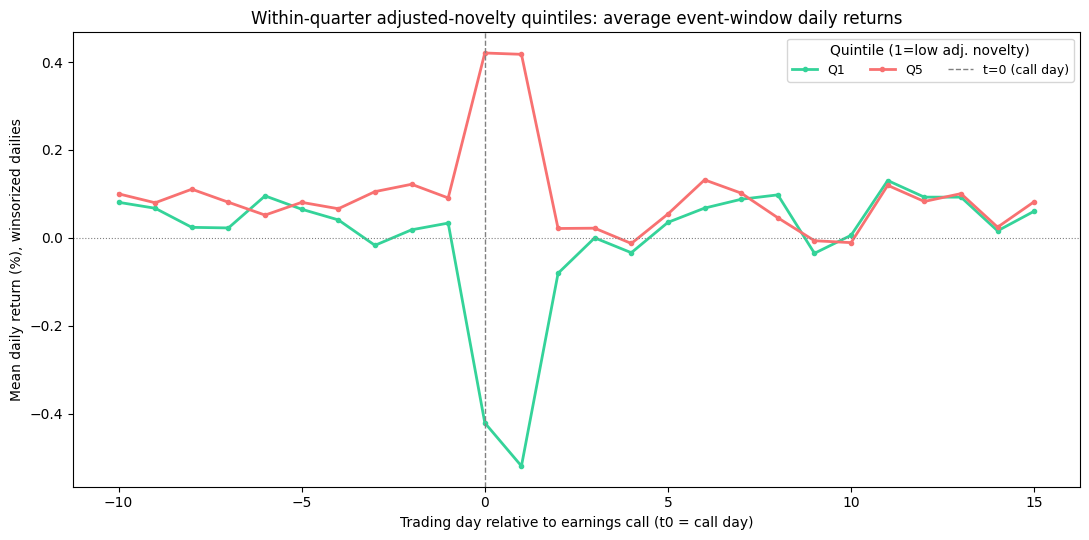

In [36]:
import os
# ── Event-time daily returns by novelty quintile (t−10 … t+15) ───────────────
# `nh.merge_event_panel_into_firm_quarter` drops raw `ret_t*` after forming CARs;
# merge winsorized dailies back from `df` for this path chart.

import matplotlib.pyplot as plt

RET_EVENT_BAND = [f"ret_t{j}" for j in list(range(-10, 0)) + list(range(0, 16))]
_missing = [c for c in RET_EVENT_BAND if c not in df.columns]
if _missing:
    raise RuntimeError(f"df missing return columns (run §1b pipeline first): {_missing[:6]}")

_panel = df[["ticker", "quarter_str"] + RET_EVENT_BAND].drop_duplicates(
    ["ticker", "quarter_str"], keep="last"
)
fqs_daily = fqs.merge(_panel, on=["ticker", "quarter_str"], how="inner")
by_q = fqs_daily.groupby("novelty_quintile")[RET_EVENT_BAND].mean()
days = list(range(-10, 16))

print(
    f"Firm-quarters in fqs with matching daily returns: {len(fqs_daily):,} "
    f"(of {len(fqs):,} in fqs)"
)

fig_ev, ax_ev = plt.subplots(figsize=(11, 5.5))
colors_q = {1.0: "#34d399", 2.0: "#60a5fa", 3.0: "#f5a623", 4.0: "#fb923c", 5.0: "#f87171"}
for q in sorted(by_q.index[[0,4]].dropna(), key=lambda x: float(x)):
    ax_ev.plot(
        days,
        by_q.loc[q].values * 100.0,
        marker="o",
        ms=3,
        lw=2,
        color=colors_q.get(float(q), "#888888"),
        label=f"Q{int(float(q))}",
    )

ax_ev.axvline(0, color="gray", ls="--", lw=1, label="t=0 (call day)")
ax_ev.axhline(0, color="gray", ls=":", lw=0.8)
ax_ev.set_xlabel("Trading day relative to earnings call (t0 = call day)")
ax_ev.set_ylabel("Mean daily return (%), winsorized dailies")
ax_ev.set_title(
    "Within-quarter adjusted-novelty quintiles: average event-window daily returns"
)
ax_ev.legend(title="Quintile (1=low adj. novelty)", ncol=3, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DATASET, "quintile_event_time_returns.png"), dpi=150, bbox_inches="tight")
plt.show()


In [37]:
# (removed debug fragment)

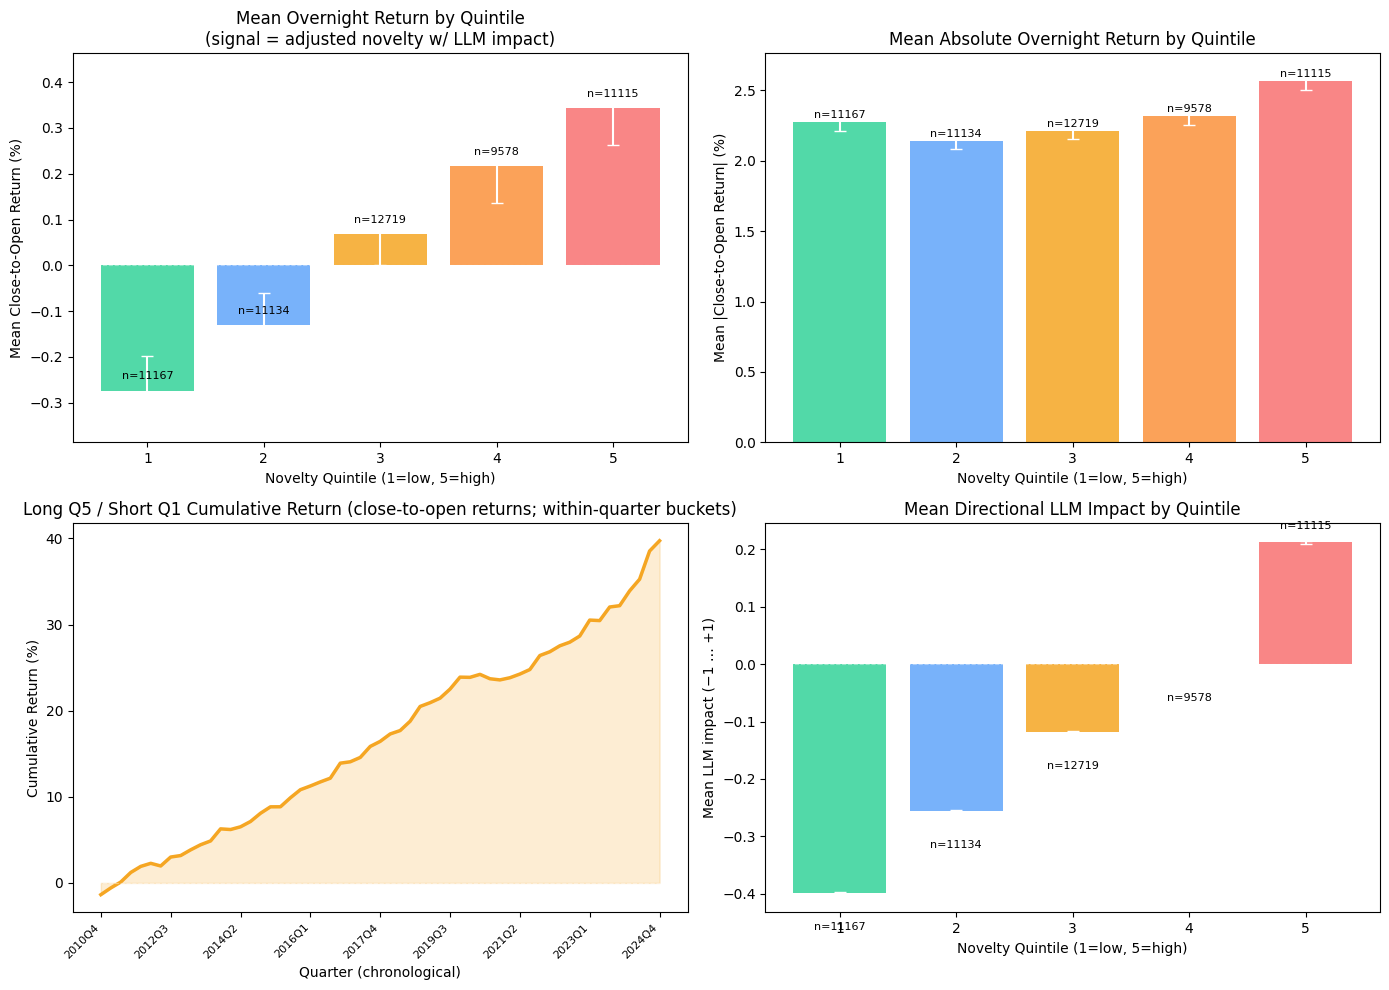

In [38]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Mean signed return by quintile ─────────────────────────────────────────
quintile_returns = (fqs.groupby("novelty_quintile")["close_to_open_return"]
                    .agg(["mean","sem","count"])
                    .reset_index())

colors = ["#34d399","#60a5fa","#f5a623","#fb923c","#f87171"]
ax = axes[0, 0]
bars = ax.bar(
    quintile_returns["novelty_quintile"],
    quintile_returns["mean"] * 100,
    color=colors,
    alpha=0.85, edgecolor="none"
)
ax.errorbar(
    quintile_returns["novelty_quintile"],
    quintile_returns["mean"] * 100,
    yerr=quintile_returns["sem"] * 100 * 1.96,
    fmt="none", color="white", capsize=4, linewidth=1.5
)
ax.axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xlabel("Novelty Quintile (1=low, 5=high)")
ax.set_ylabel("Mean Close-to-Open Return (%)")
ax.set_title("Mean Overnight Return by Quintile\n(signal = adjusted novelty w/ LLM impact)")
ax.set_xticks([1,2,3,4,5])
for bar, (_, row) in zip(bars, quintile_returns.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"n={int(row['count'])}",
                 ha="center", va="bottom", fontsize=8)

# ── Mean absolute return by quintile ────────────────────────────────────────
quintile_abs = (
    fqs.groupby("novelty_quintile")["close_to_open_return"]
    .agg(
        mean_abs=lambda s: float(s.abs().mean()),
        sem_abs=lambda s: float(s.abs().sem()) if len(s) > 1 else 0.0,
        count="count",
    )
    .reset_index()
)
quintile_abs["sem_abs"] = quintile_abs["sem_abs"].fillna(0.0)

ax = axes[0, 1]
bars_abs = ax.bar(
    quintile_abs["novelty_quintile"],
    quintile_abs["mean_abs"] * 100,
    color=colors,
    alpha=0.85,
    edgecolor="none",
)
ax.errorbar(
    quintile_abs["novelty_quintile"],
    quintile_abs["mean_abs"] * 100,
    yerr=quintile_abs["sem_abs"] * 100 * 1.96,
    fmt="none",
    color="white",
    capsize=4,
    linewidth=1.5,
)
ax.set_xlabel("Novelty Quintile (1=low, 5=high)")
ax.set_ylabel("Mean |Close-to-Open Return| (%)")
ax.set_title("Mean Absolute Overnight Return by Quintile")
ax.set_xticks([1, 2, 3, 4, 5])
for bar, (_, row) in zip(bars_abs, quintile_abs.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"n={int(row['count'])}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

# ── Long-short backtest: Q5 long, Q1 short ─────────────────────────────────
fqs_sorted = fqs.sort_values("quarter_str")
ls_by_quarter = (
    fqs_sorted[fqs_sorted["novelty_quintile"].isin([1, 5])]
    .groupby(["quarter_str", "novelty_quintile"])["close_to_open_return"]
    .mean()
    .unstack()
    .rename(columns={1: "short_Q1", 5: "long_Q5"})
    .dropna()
)
ls_by_quarter["long_short"] = ls_by_quarter["long_Q5"] - ls_by_quarter["short_Q1"]
ls_by_quarter["cumulative_ls"] = (1 + ls_by_quarter["long_short"]).cumprod() - 1

ax = axes[1, 0]
ax.plot(range(len(ls_by_quarter)),
             ls_by_quarter["cumulative_ls"] * 100,
             color="#f5a623", linewidth=2.5)
ax.fill_between(range(len(ls_by_quarter)),
                      0, ls_by_quarter["cumulative_ls"] * 100,
                      alpha=0.2, color="#f5a623")
ax.axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xlabel("Quarter (chronological)")
ax.set_ylabel("Cumulative Return (%)")
ax.set_title("Long Q5 / Short Q1 Cumulative Return (close-to-open returns; within-quarter buckets)")
ax.set_xticks(range(0, len(ls_by_quarter), max(1, len(ls_by_quarter)//8)))
ax.set_xticklabels(
    ls_by_quarter.index[::max(1, len(ls_by_quarter)//8)],
    rotation=45, ha="right", fontsize=8
)

# ── Mean LLM impact score by quintile ───────────────────────────────────────
impact_q = (
    fqs.groupby("novelty_quintile")["mean_llm_impact"]
    .agg(["mean", "sem", "count"])
    .reset_index()
)
impact_q["sem"] = impact_q["sem"].fillna(0.0)
ax = axes[1, 1]
bars_i = ax.bar(
    impact_q["novelty_quintile"],
    impact_q["mean"],
    color=colors,
    alpha=0.85,
    edgecolor="none",
)
ax.errorbar(
    impact_q["novelty_quintile"],
    impact_q["mean"],
    yerr=impact_q["sem"] * 1.96,
    fmt="none",
    color="white",
    capsize=4,
    linewidth=1.5,
)
ax.axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xlabel("Novelty Quintile (1=low, 5=high)")
ax.set_ylabel("Mean LLM impact (−1 … +1)")
ax.set_title("Mean Directional LLM Impact by Quintile")
ax.set_xticks([1, 2, 3, 4, 5])
for bar, (_, row) in zip(bars_i, impact_q.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (0.02 if row["mean"] >= 0 else -0.05),
        f"n={int(row['count'])}",
        ha="center",
        va="bottom" if row["mean"] >= 0 else "top",
        fontsize=8,
    )

plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DATASET, "backtest_results.png"), dpi=120, bbox_inches="tight")
plt.show()


In [39]:
# Summary statistics
print("=" * 55)
print("STRATEGY PERFORMANCE SUMMARY")
print("=" * 55)

q1 = fqs[fqs["novelty_quintile"] == 1]["close_to_open_return"]
q5 = fqs[fqs["novelty_quintile"] == 5]["close_to_open_return"]
ls = ls_by_quarter["long_short"]

def sharpe(returns, periods_per_year=4):
    """Annualized Sharpe (quarterly observations)."""
    return (returns.mean() / returns.std()) * (periods_per_year ** 0.5)

print(f"{'Metric':<35} {'Q1 (Low Nov.)':>14} {'Q5 (High Nov.)':>15} {'L-S':>10}")
print("-" * 75)
print(f"{'Mean return':<35} {q1.mean()*100:>13.3f}% {q5.mean()*100:>14.3f}% "
      f"{ls.mean()*100:>9.3f}%")
print(f"{'Std dev':<35} {q1.std()*100:>13.3f}% {q5.std()*100:>14.3f}% "
      f"{ls.std()*100:>9.3f}%")
print(f"{'Hit rate (return > 0)':<35} {(q1>0).mean():>14.1%} {(q5>0).mean():>14.1%} "
      f"{(ls>0).mean():>9.1%}")
print(f"{'Annualized Sharpe':<35} {sharpe(q1):>14.3f} {sharpe(q5):>14.3f} "
      f"{sharpe(ls):>9.3f}")
print(f"{'Observations':<35} {len(q1):>14,} {len(q5):>14,} {len(ls):>9,}")
print("=" * 55)


STRATEGY PERFORMANCE SUMMARY
Metric                               Q1 (Low Nov.)  Q5 (High Nov.)        L-S
---------------------------------------------------------------------------
Mean return                                -0.273%          0.344%     0.590%
Std dev                                     4.027%          4.340%     0.578%
Hit rate (return > 0)                        47.9%          52.9%     87.7%
Annualized Sharpe                           -0.136          0.158     2.043
Observations                                11,167         11,115        57


## 8. Diagnostics — PDF §5 (EDA-style)

### 8.1 Novelty by Cluster — which clusters drive the short signal?


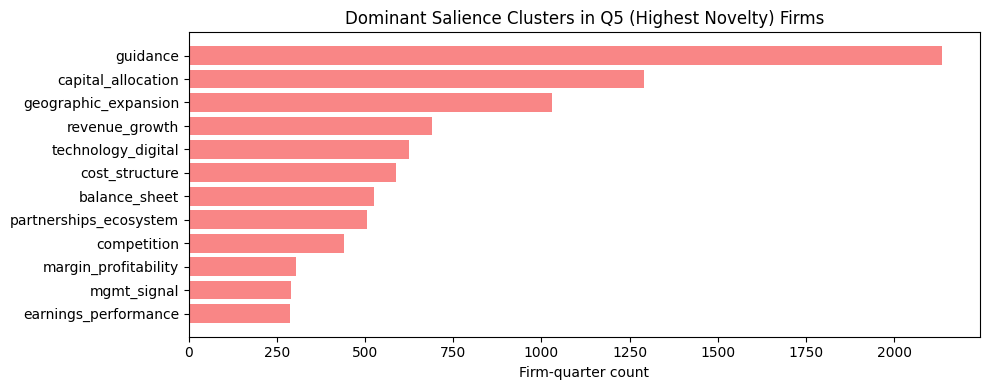

Interpretation: clusters dominating Q5 represent the types of topics
that markets tend to overprice when firms discuss them for the first time.


In [40]:
import os
# Q5 dominant clusters
q5_firms = fqs[fqs["novelty_quintile"] == 5]
q5_clusters = (q5_firms["dominant_cluster"]
               .value_counts()
               .head(12))

plt.figure(figsize=(10, 4))
plt.barh(q5_clusters.index[::-1], q5_clusters.values[::-1], color="#f87171", alpha=0.85)
plt.title("Dominant Salience Clusters in Q5 (Highest Novelty) Firms", fontsize=12)
plt.xlabel("Firm-quarter count")
plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DATASET, "q5_clusters.png"), dpi=120, bbox_inches="tight")
plt.show()

print("Interpretation: clusters dominating Q5 represent the types of topics")
print("that markets tend to overprice when firms discuss them for the first time.")


### 8.2 Novelty score vs. return scatter

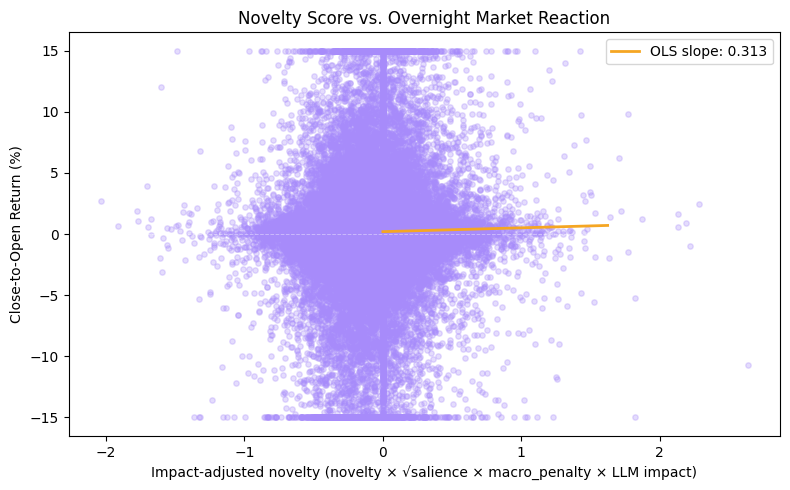

OLS coefficient: 0.3134
Positive slope supports thesis: high impact + novelty + salience  → higher overnight return


In [41]:
import os
plt.figure(figsize=(8, 5))
plt.scatter(
    fqs["mean_adjusted_novelty"],
    fqs["close_to_open_return"] * 100,
    alpha=0.3, s=15, color="#a78bfa"
)

# OLS trend line
from numpy.polynomial import polynomial as P
x = np.sqrt(fqs["mean_adjusted_novelty"].values)
y = fqs["close_to_open_return"].values * 100
mask = np.isfinite(x) & np.isfinite(y)
coef = np.polyfit(x[mask], y[mask], 1)
xline = np.linspace(x[mask].min(), x[mask].max(), 100)
plt.plot(xline, np.polyval(coef, xline), color="#f5a623", linewidth=2,
         label=f"OLS slope: {coef[0]:.3f}")
plt.axhline(0, color="white", linewidth=0.7, linestyle="--", alpha=0.4)
plt.xlabel("Impact-adjusted novelty (novelty × √salience × macro_penalty × LLM impact)")
plt.ylabel("Close-to-Open Return (%)")
plt.title("Novelty Score vs. Overnight Market Reaction")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(GDRIVE_DATASET, "novelty_vs_return.png"), dpi=120, bbox_inches="tight")
plt.show()

print(f"OLS coefficient: {coef[0]:.4f}")
print("Positive slope supports thesis: high impact + novelty + salience  → higher overnight return")


## 9. Example signals (illustration)

Pull example **long** and **short** candidates from the most recent quarter using the **signed impact-adjusted** firm-quarter signal.


In [42]:
most_recent_q = fqs["quarter_str"].max()
cols = [
    "ticker",
    "quarter_str",
    "mean_adjusted_novelty_pre",
    "mean_adjusted_novelty",
    "mean_llm_impact",
    "mean_novelty",
    "mean_salience",
    "macro_penalty",
    "dominant_cluster",
    "n_novel_turns",
    "close_to_open_return",
]

qdf = fqs[fqs["quarter_str"] == most_recent_q]

top_longs = qdf.nlargest(10, "mean_adjusted_novelty")[cols]
top_shorts = qdf.nsmallest(10, "mean_adjusted_novelty")[cols]

print(f"Top Long Candidates (Q5, most positive impact-adjusted) — {most_recent_q}")
print(top_longs.to_string(index=False))
print("\nTop Short Candidates (Q1, most negative impact-adjusted) —", most_recent_q)
print(top_shorts.to_string(index=False))


Top Long Candidates (Q5, most positive impact-adjusted) — 2024Q4
ticker quarter_str  mean_adjusted_novelty_pre  mean_adjusted_novelty  mean_llm_impact  mean_novelty  mean_salience  macro_penalty       dominant_cluster  n_novel_turns  close_to_open_return
  GKOS      2024Q4                   2.048687               1.434081             0.70      0.624595         10.850       0.995777     healthcare_biotech              1             -0.048561
  ASAN      2024Q4                   2.030570               1.421399             0.70      0.642376         10.342       0.982938     technology_digital              1              0.150000
   CNO      2024Q4                   1.710857               1.368686             0.80      0.678458          6.500       0.989086      macro_environment              1              0.001670
   BCP      2024Q4                   2.690167               1.345084             0.50      0.688972         15.500       0.991772   margin_profitability              1        

In [43]:
# Inspect the highest impact-adjusted segments for a top candidate
# (use top_longs for Q5-style positive names; top_shorts for Q1-style negative names)
top_ticker = top_longs.iloc[0]["ticker"]
top_q      = top_longs.iloc[0]["quarter_str"]

top_sents = (signal_df[
    (signal_df["ticker"] == top_ticker) &
    (signal_df["quarter_str"] == top_q)
]
.nlargest(5, "adjusted_novelty")
[["sentence","novelty_score","salience_score","top_cluster",
  "adjusted_novelty_pre_impact","adjusted_novelty","llm_impact_score"]])

print(f"\n=== Top impact-adjusted segments: {top_ticker} {top_q} ===\n")
for _, row in top_sents.iterrows():
    print(f"Cluster  : {row['top_cluster']}")
    print(
        f"Novelty  : {row['novelty_score']:.3f}  |  Salience: {row['salience_score']:.3f}  "
        f"|  Adj pre-impact: {row['adjusted_novelty_pre_impact']:.4f}  "
        f"|  LLM impact: {row['llm_impact_score']:.3f}  "
        f"|  Adj final: {row['adjusted_novelty']:.4f}"
    )
    print(f"Sentence : {row['sentence'][:200]}")
    print()



=== Top impact-adjusted segments: GKOS 2024Q4 ===

Cluster  : healthcare_biotech
Novelty  : 0.625  |  Salience: 10.850  |  Adj pre-impact: 2.0487  |  LLM impact: 0.700  |  Adj final: 1.4341
Sentence : Yes, Allen, I'd be happy to answer that. And so let's take a step back and really talk about [ Epi-on, ] which we think is a significant advancement and really the result of years of innovation work a



## 10. Discussion — PDF §2 mechanism & implementation gaps

### What this implements from the strategy paper
| Step | Paper | Implementation |
|------|-------|----------------|
| Baseline Build | Per-firm TF-IDF vocabulary profile | ✅ Rolling TF-IDF per firm-quarter |
| Semantic Check | Sentence embeddings + cosine distance | ✅ `EMBEDDING_MODEL_NAME` (default MiniLM; swap to Nomic via config + new cache tag) |
| Text unit | Q&A turns / segments | ✅ Turn-aligned segments via `transcript_speaker_indices.csv` + **Q&A-only** filter (prepared remarks excluded by default) |
| Empirical panel | `FINAL.csv` + controls | ✅ Returns window + I/B/E/S (`ibes_sue_eps`, surprises); **market cap** still needs merge |
| Intent Verify | LLM binary classifier (YES/NO) | ✅ Salience threshold + **Ollama YES/NO** intent cache (precision gate) |
| Impact direction | LLM directional impact score | ✅ Ollama **`llm_impact_score` ∈ [−1,+1]** + signed impact-adjusted novelty |
| Macro Adjust | Cross-sectional frequency discount | ✅ Cluster × quarter firm-frequency penalty |

### Why `all-MiniLM-L6-v2` and not FinBERT for embeddings
FinBERT is fine-tuned on financial text for **sentiment classification** (positive/negative/neutral). Its internal representations encode sentiment polarity — the cosine distance between two FinBERT embeddings measures how different their *sentiment* is, not how *semantically novel* one sentence is relative to historical context. Using FinBERT embeddings for novelty detection would flag positive-vs-negative sentence pairs as "novel" even if they discuss identical topics, and would fail to flag genuinely new vocabulary.

`all-MiniLM-L6-v2` is trained on paraphrase and semantic textual similarity tasks — its embedding space preserves meaning such that cosine distance is a valid measure of semantic novelty.

### Limitations & extensions
- **Look-ahead bias:** Ensure baseline only includes transcripts strictly before the event quarter (✅ implemented)
- **Model staleness:** A firm that legitimately pivots will generate persistent false signals — re-weight baseline with recency decay
- **LLM intent/impact:** We now cache both **intent (YES/NO)** and **directional impact** per segment; remaining work is calibration/validation of prompts and robustness across models.
- **Return horizon:** Many plots here use the **overnight close-to-open** return for a tight “reaction” proxy. A cleaner test of H1 in calendar time is a true **holding-period** long–short built from post-event returns (e.g., +2 to +20 trading days) with risk adjustment.
- **Short execution:** Entry timing (after spike confirmation), borrowing costs, and bid-ask spread are not modeled here


In [44]:
import os
signal_df.to_csv(os.path.join(GDRIVE_DATASET, "signal_df.csv"))

In [45]:
import os
# chunk_index → speaker_indices mapping (mode-aware)
#
# Produces a chunk_to_component-style table keyed by (transcriptid, chunk_index).
# - novelty_mode == 'turns': uses exec_chunks.exec_turn_index → raw_turn_df.turn_index → componentorder.
# - novelty_mode == 'full_turns': rebuilds the filtered+truncated FULL_TURNS position map.
# - novelty_mode == 'chunk': no 1-1 mapping to speaker_indices (componentorder left NaN).

chunk_to_component = build_chunk_to_component_for_signal_df(signal_df, raw_turn_df, exec_chunks)

_cols = [
    "novelty_mode",
    "transcriptid",
    "chunk_index",
    "exec_turn_index",
    "componentorder",
    "transcriptcomponentid",
    "speakertypename",
]
for c in _cols:
    if c not in chunk_to_component.columns:
        chunk_to_component[c] = np.nan

chunk_to_component[_cols].to_csv(os.path.join(GDRIVE_DATASET, "chunk_to_component.csv"), index=False)

print(f"chunk_to_component rows: {len(chunk_to_component):,} → wrote chunk_to_component.csv")
chunk_to_component.head(10)


chunk_to_component rows: 152,509 → wrote chunk_to_component.csv


,transcriptid,chunk_index,novelty_mode,signal_text,turn_index,componentorder,transcriptcomponentid,speakertypename,turn_text,map_mode,exec_turn_index,chunk_text,exec_text
146711,79809,15,full_turns,Not specifically. They're waiting for this thi...,15,15,5729980,Executives,Not specifically. They're waiting for this thi...,full_turns,NaN,NaN,NaN
146712,79809,31,full_turns,I would assume mostly very liquid. I wouldn't ...,31,31,5729996,Executives,I would assume mostly very liquid. I wouldn't ...,full_turns,NaN,NaN,NaN
146713,79809,39,full_turns,Is it fair to assume that at least a fair port...,39,39,5730004,Analysts,Is it fair to assume that at least a fair port...,full_turns,NaN,NaN,NaN
146714,79809,104,full_turns,deal? I confess multiple times that one of the...,108,108,5730073,Executives,deal? I confess multiple times that one of the...,full_turns,NaN,NaN,NaN
146715,79809,143,full_turns,Research. Maybe just a quick follow-up on Base...,149,149,5730114,Analysts,Research. Maybe just a quick follow-up on Base...,full_turns,NaN,NaN,NaN
37325,80117,10,full_turns,"And then second question, Todd, helpful in ter...",10,10,5749257,Analysts,"And then second question, Todd, helpful in ter...",full_turns,NaN,NaN,NaN
37326,80117,18,full_turns,That's correct. And you've got to remember we ...,18,18,5749265,Executives,That's correct. And you've got to remember we ...,full_turns,NaN,NaN,NaN
37327,80117,25,full_turns,"Sure. Under Basel II, there are capital requir...",26,26,5749273,Executives,"Sure. Under Basel II, there are capital requir...",full_turns,NaN,NaN,NaN
55958,81640,11,full_turns,"But guidance in terms of accretions, kind of w...",11,11,5848338,Analysts,"But guidance in terms of accretions, kind of w...",full_turns,NaN,NaN,NaN
55959,81640,16,full_turns,"On the regulatory front, there are no regulato...",16,16,5848343,Executives,"On the regulatory front, there are no regulato...",full_turns,NaN,NaN,NaN


In [46]:
from google.colab import runtime
runtime.unassign()